### **Кейс**



К нам обратился клиент, который занимается сборкой и продажей персональных компьютеров (за исключением мини-ПК и моноблоков). В связи с ростом популярности интернет-магазинов, таких как Wildberries, Ozon, OnlineTrade и т. п., за последние несколько лет, а также с целью привлечения большего числа клиентов при одновременном снижении затрат на содержание собственного магазина, доставку и рекламу товаров он планирует выйти на онлайн-рынок. В связи с этим клиент хотел бы узнать, от чего зависит цена, а также популярность персональных компьютеров, выкладываемых на онлайн-площадках, чтобы в дальнейшем планировать к сборке востребованные по техническим характеристикам компьютеры и продавать их по конкурентной цене.

Специалистом по сбору данных был выгружен [файл в формате csv](https://drive.google.com/file/d/1XcWVR-PNPZPbADjhuTVvT_RN_EXiYUBy/view?usp=sharing) с одного из популярных онлайн-магазинов, содержащий информацию о товарах категории «Компьютеры и моноблоки».
Проанализируйте полученные данные и представьте аналитический отчет, содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения своих бизнес-задач.

### **Бизнес-цель Заказчика**

Создание интернет-магазина персональных компьютеров без мини-компьютеров и моноблоков в целях увеличения числа клиентов в полтора раза за счет привлекательной цены и востребованности собираемого ПК, а также в целях сокращения затрат на 50% с июля по декабрь 2023 г..

### **Цель анализа данных**

Анализ цены и востребованности собираемого ПК в интернет-магазине.





### **Объекты исследования**

1. Цена на компьютеры, ее зависимость от комплектующих, ценовая вилка.
2. Востребованность, выраженная в количестве продаж, и ее зависимость от комплектующих (заказчик хочет знать о наиболее популярных комплектующих, продаваемых в составе компьютеров).


### **Предметы исследования**

Комплектующие / технические характеристики собираемых ПК.







### **Обзор данных, выявление проблем**

Данные в датасете, представленном Заказчиком, взяты с сайта Wildberries, товар на сайте находится по product_id (артикулу). В результате ручной сверки нескольких товарных позиций по цене из датасета и по цене на сайте на один и тот же товар обнаружилось, что некоторые цены существенно различаются, что делает датасет недостоверным, поэтому я не буду пользоваться данными Заказчика, а соберу их с [сайта Wildberries](https://www.wildberries.ru/catalog/elektronika/noutbuki-periferiya/kompyutery) заново. Данные из файла Заказчика брать не буду, он мне понадобится только для сверки позиций, чтобы знать, что, собственно, нужно анализировать. Сбор провожу исключительно с Wildberries, поскольку считаю, раз Заказчик брал данные именно отсюда, значит, здесь и собирается открывать свою площадку.

### **Сбор и очистка данных**

Так как у Wildberries динамический сайт, воспользуюсь кодом из [этих видео](https://www.youtube.com/playlist?list=PLK9kK8z0fpqwbbUd39-9nkLY2Xh4FeBVT), переписав его под свои задачи.
Для реализации парсинга требуются **библиотеки requests** (для отправки HTTP-запросов и получения HTML-кода страницы с товарами) **и pydantic** (для структурирования и организации полученных данных). При написании кода используется **ООП**.
Необходимые для работы кода файлы возьму [здесь](https://github.com/Duff89/wildberries_parser).

In [ ]:
!pip install pydantic==1.10.8
!pip install requests==2.31.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.3 MB/s eta 0:00:00
  Attempting uninstall: pydantic
    Found existing installation: pydantic 1.10.12
    Uninstalling pydantic-1.10.12:
      Successfully uninstalled pydantic-1.10.12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.27.1
    Uninstalling requests-2.27.1:
      Successfully uninstalled requests-2.27.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.27.1, but you have requests 2.31.0 which is incompatible.


In [ ]:
# Для анализа нужны 'product_id', 'title', 'brand', 'price', 'rating', 'sales', 'params'
from pydantic import BaseModel, root_validator


class Item(BaseModel):
    '''subjectId: int'''
    id: int
    name: str
    brand: str
    salePriceU: float
    reviewRating: float
    '''qnt: int
    grouped_options: list'''


    @root_validator(pre=True)
    def convert_sale_price(cls, values: dict):
        sale_price = values.get("salePriceU")
        if sale_price is not None:
            values["salePriceU"] = sale_price / 100
        return values


class Items(BaseModel):
    products: list[Item]

In [ ]:
# Для анализа нужны 'product_id', 'title', 'brand', 'price', 'rating', 'sales', 'params'
import requests
import re
import csv


class ParseWB:
    def __init__(self, url: str):
        self.cat_id = self.__get_cat_id(url)

    @staticmethod
    def __get_cat_id(url: str):
        regex = "(?<=cat=).+(?=&dest)"
        cat_id = re.search(regex, url)[0]
        return cat_id

    def parse(self):
        _page = 1
        self.__create_csv()
        while True:
            response = requests.get(
                f'https://catalog.wb.ru/catalog/electronic15/catalog?cat={self.cat_id}&dest=-1257786&page={_page}',
            )
            _page += 1
            items_info = Items.parse_obj(response.json()["data"])
            if not items_info.products:
                break
            self.__save_csv(items_info)

    def __create_csv(self):
        with open("wb_data_1.csv", mode="w", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            writer.writerow(['product_id', 'title', 'brand', 'price', 'rating'])

    def __save_csv(self, items):
        with open("wb_data_1.csv", mode="a", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            for product in items.products:
                writer.writerow([product.id,
                                 product.name,
                                 product.brand,
                                 product.salePriceU,
                                 product.reviewRating])


if __name__ == "__main__":
    ParseWB("https://catalog.wb.ru/catalog/electronic15/catalog?cat=9963&dest=-1257786").parse()

У меня не получилось вписать в код количество продаж и технические характеристики, не хватает пока знаний и опыта, чтобы довести [решение](https://drive.google.com/file/d/1G3gow7U9XoRdRj3PN7zBjFNBlUA2eIhi/view?usp=sharing) до конца. Тьютор Мария предложила свой парсер:

In [ ]:
# For VS Code:
# -*- coding: utf8 -*-
import time, csv, ssl

from selenium.webdriver import ActionChains, Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium import webdriver
import undetected_chromedriver as uc

ssl._create_default_https_context = ssl._create_unverified_context
options = Options()

options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-notifications")

driver = uc.Chrome(options=options)


for page in range(1, 70):
    '''Создание csv файла для новой страницы'''
    with open(f'wb_computer_page{page}.csv', 'w', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['product id', 'title', 'rating', 'price', 'sales', 'feedbacks', 'seller', 'seller rating', 'Процессор', 'Оперативная память', 'Жесткий диск', 'Видеопроцессор', 'Операционная система', 'Гарантийный срок', 'Страна производства', 'Габариты товара', 'Габариты с упаковкой'])

    driver.get(f'https://www.wildberries.ru/catalog/elektronika/noutbuki-periferiya/kompyutery?page={page}')
    time.sleep(60)

    '''Список с ссылками на странице (которые нужны для парсинга), каждый раз с новым циклом собирается заново'''
    for i in range(20):
        ActionChains(driver).send_keys(Keys.END).perform()
        time.sleep(1)

    links_for_check = [link.find_element(By.CLASS_NAME, 'product-card__link').get_attribute('href') for link in driver.find_elements(By.CLASS_NAME, 'product-card--hoverable')]
    print(len(links_for_check))
    for page_pars in links_for_check:
        print('Сейчас идет парсинг страницы - ', page_pars)

        driver.get(page_pars)
        time.sleep(10)
        try:
            product_id = driver.find_element(By.ID, 'productNmId').text.strip(' ')
        except:
            product_id = ''
        try:
            title = driver.find_element(By.CLASS_NAME, 'product-page__header').find_element(By.TAG_NAME, 'h1').text.strip(' ')
        except:
            title = ''
        try:
            rating = driver.find_element(By.CLASS_NAME, 'product-review__rating').text.strip(' ')
        except:
            rating = ''
        try:
            price = ''.join([x for x in driver.find_elements(By.CLASS_NAME, 'price-block__final-price')[0].text if x in '0123456789']) #+ '₽'
        except:
            price = ''
        try:
            sales = driver.find_element(By.CLASS_NAME, 'product-order-quantity').text.strip(' ')
        except:
            sales = ''
        try:
            feedbacks = driver.find_element(By.CLASS_NAME, 'product-review__count-review').text.strip(' ')
        except:
            feedbacks = ''

        try:
            try:
                seller = driver.find_element(By.CLASS_NAME, 'seller-info__name').text.strip(' ')
            except:
                seller = driver.find_element(By.CLASS_NAME, 'seller-info__default-name').text.strip(' ')
        except:
            seller = ''

        try:
            seller_rating = driver.find_element(By.CLASS_NAME, 'seller-info__param').find_element(By.CLASS_NAME, 'address-rate-mini').text.strip(' ')
        except:
            seller_rating = ''

        '''Раскрытие элемента с характеристиками'''
        try:
            ActionChains(driver).move_to_element(driver.find_element(By.CLASS_NAME, 'j-parameters-btn')).perform()
            driver.execute_script("window.scrollBy(0, 200)")
            driver.find_element(By.CLASS_NAME, 'j-parameters-btn').click()
            time.sleep(0.1)
        except:
            pass

        processor = ''
        memory = ''
        sata = ''
        video = ''
        system = ''
        guarantee = ''
        made_in = ''
        size = ''
        size_with_pack = ''
        for i in driver.find_elements(By.CLASS_NAME, 'product-params__table'):
            if 'Процессор' in i.text:
                processor = i.find_element(By.TAG_NAME, 'tbody').text.strip(' ')
            if 'Память' in i.text:
                memory = i.find_element(By.TAG_NAME, 'tbody').text.strip(' ')
            if 'Накопители данных' in i.text:
                sata = i.find_element(By.TAG_NAME, 'tbody').text.strip(' ')
            if 'Видеокарта' in i.text:
                video = i.find_element(By.TAG_NAME, 'tbody').text.strip(' ')
            if 'Общие характеристики' in i.text:
                for j in i.find_elements(By.CLASS_NAME, 'product-params__row'):
                    if 'Операционная система' in j.text:
                        system = j.find_elements(By.CLASS_NAME, 'product-params__cell')[-1].text.strip(' ')
                    if 'Гарантийный срок' in j.text:
                        guarantee = j.find_elements(By.CLASS_NAME, 'product-params__cell')[-1].text.strip(' ')
            if 'Дополнительная информация' in i.text:
                for j in i.find_elements(By.CLASS_NAME, 'product-params__row'):
                    if 'Страна производства' in j.text:
                        made_in = j.find_elements(By.CLASS_NAME, 'product-params__cell')[-1].text.strip(' ')
            if 'Габариты' in i.text:
                for j in i.find_elements(By.CLASS_NAME, 'product-params__row'):
                    if 'Высота предмета' in j.text or 'Ширина предмета' in j.text or 'Глубина предмета' in j.text or 'Вес без упаковки (кг)' in j.text:
                        size += j.text.strip(' ') + ','
                    if 'Длина упаковки' in j.text or 'Высота упаковки' in j.text or 'Ширина упаковки' in j.text or 'Вес с упаковкой (кг)' in j.text:
                        size_with_pack += j.text.strip(' ') + ','

        size = size.strip(',')
        size_with_pack = size_with_pack.strip(',')

        with open(f'wb_computer_page{page}.csv', 'a', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow([product_id, title, rating, price, sales, feedbacks, seller, seller_rating, processor, memory, sata, video, system, guarantee, made_in, size, size_with_pack])


Файлы собирались постранично, затем были [сведены](https://products.aspose.app/cells/ru/merger/csv) в [один](https://drive.google.com/file/d/1ufr0r0GJiH6iuLGWPNDcN6uyRuYDccDp/view?usp=sharing).

Поскольку на написание рабочего парсера ушло много времени и его еще пришлось подгонять под сайт (например, увеличивать время сна на страницу до минуты, чтобы со страниц не собиралось лишь 10 товаров из 100), скорость моего мобильного интернета низкая, сам сбор длится очень долго, для анализа я собрала данные с первых 20 страниц раздела с отсортированными по популярности компьютерами из 69 имеющихся. На сбор этих 20 страниц ушло более 13 часов. В будущем я планирую все же освоить сбор данных с помощью библиотек requests и pydantic, который в VS Code проходит за пару секунд.

Проведу очистку данных.

In [ ]:
import pandas as pd
import re

In [ ]:
# Скачаю файл со своими собранными данными с гугл-диска
!gdown --id 1ufr0r0GJiH6iuLGWPNDcN6uyRuYDccDp

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ufr0r0GJiH6iuLGWPNDcN6uyRuYDccDp
To: /content/wb_data.csv
100% 5.68M/5.68M [00:00<00:00, 166MB/s]


In [ ]:
# Сохраню датафрейм в переменную df
df = pd.read_csv('wb_data.csv')

In [ ]:
# Создам копию для работы и сохраню ее в переменную df1
df1=df.copy()

In [ ]:
# Проведу визуальный обзор датафрейма
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Columns: 1001 entries, product id to Unnamed: 1000
dtypes: float64(984), object(17)
memory usage: 22.9+ MB


In [ ]:
# Проверю любую строку из датафрейма
df1.sample(1)

,product id,title,rating,price,sales,feedbacks,seller,seller rating,Процессор,Оперативная память,...,Unnamed: 991,Unnamed: 992,Unnamed: 993,Unnamed: 994,Unnamed: 995,Unnamed: 996,Unnamed: 997,Unnamed: 998,Unnamed: 999,Unnamed: 1000
1416,152957785,Игровой компьютер,Нет оценок,88580,NaN,NaN,Personal PC,NaN,Тактовая частота процессора 2600 МГц\nКоличест...,Тип оперативной памяти DDR 4\nОбъем оперативно...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Выведу названия столбцов
df1.columns

Index(['product id', 'title', 'rating', 'price', 'sales', 'feedbacks',
       'seller', 'seller rating', 'Процессор', 'Оперативная память',
       ...
       'Unnamed: 991', 'Unnamed: 992', 'Unnamed: 993', 'Unnamed: 994',
       'Unnamed: 995', 'Unnamed: 996', 'Unnamed: 997', 'Unnamed: 998',
       'Unnamed: 999', 'Unnamed: 1000'],
      dtype='object', length=1001)

In [ ]:
# Удалю все безымянные столбцы
df1.drop(columns=df1.columns[17:], inplace=True)

In [ ]:
# Посмотрю, какие теперь выводятся названия столбцов
df1.columns

Index(['product id', 'title', 'rating', 'price', 'sales', 'feedbacks',
       'seller', 'seller rating', 'Процессор', 'Оперативная память',
       'Жесткий диск', 'Видеопроцессор', 'Операционная система',
       'Гарантийный срок', 'Страна производства', 'Габариты товара',
       'Габариты с упаковкой'],
      dtype='object')

In [ ]:
# Удалю лишние столбцы
columns=['rating',
         'feedbacks',
         'seller',
         'seller rating',
         'Операционная система',
         'Гарантийный срок',
         'Страна производства',
         'Габариты товара',
         'Габариты с упаковкой']
df1.drop(columns=columns, inplace=True)

In [ ]:
# Еще раз проверю любую строку из датафрейма
df1.sample(1)

,product id,title,price,sales,Процессор,Оперативная память,Жесткий диск,Видеопроцессор
2876,145357950,Игровой компьютер B-Deep 3,101548,NaN,Процессор Intel Core i7 12700\nКоличество ядер...,Тип оперативной памяти DDR4\nОбъем оперативной...,Объем накопителя HDD 1000 Гб\nТип накопителя S...,Видеопроцессор NVIDIA GeForce RTX 3060 (12 gb)...


In [ ]:
# Проверю на дубликаты
df1.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2992     True
2993     True
2994     True
2995     True
2996     True
Length: 2997, dtype: bool

In [ ]:
# Найду количество дубликатов
df1.duplicated().sum()

1154

In [ ]:
# Удалю дубликаты
df1.drop_duplicates(inplace=True)

In [ ]:
# Проверю дубликаты по столбцу product id
df1.duplicated(subset='product id').sum()

163

In [ ]:
# Удалю дубликаты по столбцу product id, чтобы один и тот же ПК не повторялся
df1.drop_duplicates(subset='product id', inplace=True)

In [ ]:
# Оценю размеры полученного датафрейма
df1.shape

(1680, 8)

Удалю мини-компьютеры и моноблоки, а также то, что не является компьютером, из датафрейма.

In [ ]:
# Приведу все названия товаров к одному регистру - строчным буквам
df1.title = df1.title.str.lower()
df1.title

0                                       mac mini m2/8/256
1       игровой компьютер nagibator amd ryzen 5 5600g ...
2                    мощный игровой компьютер град 2.0 v3
3        игровой компьютер intel core i5 12400f rtx3060ti
4       моноблок 27" roo24 ryzen 5 4600g/ddr4 16gb/512...
                              ...                        
2892                    игровой компьютер combat m9 white
2893                    игровой компьютер combat m9 white
2894                    игровой компьютер combat m9 white
2895                         игровой компьютер kreator r4
2896           компьютер игровой пк системный блок archer
Name: title, Length: 1680, dtype: object

In [ ]:
# Найду количество уникальных товаров
print(len(df1.title.unique()))
# Выведу отсортированный список уникальных товаров
sorted(df1.title.unique())

859


['15" моноблок poscenter pos90es, черный',
 '15.6"ноутбук maibenben m555/amd ryzen 5 5500u/16 гб/512 гб',
 '23.8" моноблок асеr aspire c24-1700 (dq.bjfmc.00d)',
 '5bites вентилятор f5010s-3 подшипник 4500rpm, 24dba, 3 pin',
 'basic10wo.amd e1.ddr3 8гб.ssd120гб+hdd1000гб/windows7+офис',
 'basic7. процессор amd e1, ddr3 8гб, диск ssd 240гб',
 'beelink gk mini 8/256gb win10',
 'beelink mini s',
 'bitmain antminer s9i 14-14.5 th/s',
 'fortnite код на 1000 v-bucks',
 'god of war: ragnarok (ps4, русская озвучка)',
 'god of war: ragnarok digital deluxe',
 'imac 24/m1/8/256 (orange)',
 'lan кабель для интернета cat5e rj45 1гбит/ патч корд серый',
 'lan кабель для подключения интернет патч корд серый',
 'm119',
 'mac mini m2/8/256',
 'mac mini m2/8/512',
 'splitter 4-pin сплиттер для кулеров 12в, 1-10-molex',
 'title',
 'wi-fi usb-адаптер разъём переходник',
 'асик antminer l3+ 504 mh/s',
 'асик avalon 821 10.5-11.5 th/s 2018 год',
 'асик whatsminer m20s 68 th/s 2020 г',
 'батарейка cmos cr2032

In [ ]:
# Изменю столбец с индексами и вместо цифровых значений задам данные из столбца 'title'
df1= df1.set_index('title')
# Удалю ненужные строки
df1.drop(['15" моноблок poscenter pos90es, черный',
          '15.6"ноутбук maibenben m555/amd ryzen 5 5500u/16 гб/512 гб',
          '23.8" моноблок асеr aspire c24-1700 (dq.bjfmc.00d)',
          '5bites вентилятор f5010s-3 подшипник 4500rpm, 24dba, 3 pin',
          'beelink gk mini 8/256gb win10',
          'beelink mini s',
          'bitmain antminer s9i 14-14.5 th/s',
          'fortnite код на 1000 v-bucks',
          'god of war: ragnarok (ps4, русская озвучка)',
          'god of war: ragnarok digital deluxe',
          'imac 24/m1/8/256 (orange)',
          'lan кабель для интернета cat5e rj45 1гбит/ патч корд серый',
          'lan кабель для подключения интернет патч корд серый',
          'mac mini m2/8/256',
          'mac mini m2/8/512',
          'splitter 4-pin сплиттер для кулеров 12в, 1-10-molex',
          'title',
          'wi-fi usb-адаптер разъём переходник',
          'асик antminer l3+ 504 mh/s',
          'асик avalon 821 10.5-11.5 th/s 2018 год',
          'асик whatsminer m20s 68 th/s 2020 г',
          'батарейка cmos cr2032 с коннектором',
          'воздуходувка портативная беспроводная',
          'временно недоступен',
          'игра atomic heart',
          'игра atomic heart - gold edition',
          'игра cyberpunk 2077',
          'игра god of war ragnarok ps5',
          'игра hogwarts legacy playstation 4',
          'игра hogwarts legacy playstation 5',
          'игровой компьютер robotcomp аллигатор мини 2.0 bluetooth v2',
          'игровой компьютер robotcomp аллигатор мини 2.0 bluetooth v3',
          'игровой компьютер robotcomp аллигатор мини 2.0 v1 plus',
          'игровой компьютер robotcomp аллигатор мини 2.0 v2',
          'игровой компьютер robotcomp аллигатор мини 2.0 v2 plus',
          'игровой компьютер robotcomp аллигатор мини 2.0 v3',
          'игровой компьютер robotcomp старт мини bluetooth v2 plus',
          'игровой компьютер robotcomp старт мини bluetooth v3',
          'игровой компьютер robotcomp старт мини bluetooth v3 plus',
          'игровой компьютер robotcomp старт мини v1',
          'игровой компьютер robotcomp старт мини v1 plus',
          'игровой компьютер robotcomp старт мини v2',
          'игровой компьютер robotcomp старт мини v2 plus',
          'игровой пк robotcomp аллигатор мини 2.0 bluetooth v1 plus',
          'игровой пк robotcomp аллигатор мини 2.0 bluetooth v2 plus',
          'игровой пк robotcomp аллигатор мини 2.0 bluetooth v3 plus',
          'карта оплаты fortnite 2800 v-bucks в-баксы',
          'карта оплаты fortnite на 13500 v-bucks',
          'карта оплаты sony playstation турция 1000 лир',
          'карта оплаты sony playstation турция 200 лир',
          'карта оплаты sony playstation турция 2000 лир',
          'карта оплаты sony playstation турция 400 лир',
          'карта оплаты sony playstation турция 600 лир',
          'карта памяти microsd 16 гб',
          'карта пополнения nintendo eshop 20',
          'карта пополнения nintendo eshop 35',
          'карта пополнения nintendo eshop 50',
          'карта роблокс 1700 робаксов россия',
          'код nintendo eshop пополнение на 10 usd',
          'код активации pubg mobile 1800 uc',
          'код активации pubg mobile 3850 uc',
          'код активации pubg mobile 8100 uc',
          'компьютер, mini s12, 16гб/500гб',
          'микрокомпьютер orange pi lite',
          'мини компьютер, beelink mini s, 16/256гб',
          'мини компьютер, beelink mini s, 16/512гб',
          'мини компьютер, beelink mini s, 8гб/128гб',
          'мини пк az-0012 (intel p4415u 2x2.3ghz, 8gb, 120gb ssd)',
          'мини пк az-0017 4x1.6ghz/16gb/1tb',
          'мини пк beelink gk mini 8/128gb',
          'мини пк beelink gk mini 8/256gb',
          'мини пк beelink mini s 8/128 gb',
          'мини пк beelink mini s 8/256 gb',
          'мини пк beelink t4 pro 4/64 gb',
          'мини пк corebox, intel core i3-1215u, 16gb, 512gb, win11 pro',
          'мини пк intel celeron n5095 jk01 8+128gb',
          'мини пк t6 pro j4125 6/128g',
          'мини-компьютер, mini s12, 8гб/256гб',
          'мини-пк (неттоп)/ beelink gk mini/ 8гб/256гб/ windows 10',
          'мини-пк, beelink u59 pro, 16/512 гб',
          'моноблок',
          'моноблок 200 g4 i3 10110u/8gb/ssd256gb/21.5"fhd/uhdg/cr/win10pro',
          'моноблок 23,8" roo24 ryzen 5 4600g',
          'моноблок 23.8" i7 10610u/ 16 /ssd1024/intel uhd /w11pro',
          'моноблок 27" roo24 ryzen 5 4600g/ddr4 16gb/512gb/windows 10',
          'моноблок aspire c24-1700 (dq.bjfmc.00d)',
          'моноблок aspire c24-1700 (dq.bjfmc.00e)',
          'моноблок aspire c24-1700 (dq.bjwmc.00c)',
          'моноблок aspire c24-1700 (dq.bjwmc.00d)',
          'моноблок aspire c27-1655 (dq.bhmmc.003)',
          'моноблок az-2203 21.5"/intel i3 2x2.2 ghz/8 gb/256 gb ssd',
          'моноблок az-2404 v.2 23.8"/intel i5 2x2.5 ghz/8gb/256gb ssd',
          'моноблок az-2404/2.5ghz/16gb/512gb/23.8"',
          'моноблок az-2404/2.5ghz/8gb/256gb/23.8"',
          'моноблок az-2406 23.8"/2x2.6ghz/16g/512g',
          'моноблок az-2406/2.6ghz/16gb/512gb/23.8"',
          'моноблок az-2450 23.8"/3 3300u/8gb/512gb',
          'моноблок az-2702 27"/2x2.9ghz/16gb/512gb',
          'моноблок az-2702-3 27"/2x2.9ghz/16gb/1tb',
          'моноблок az-2704 amd ryzen 3/2.1ghz/16gb/512gb/27"',
          'моноблок az-2715 27"/i5-1240p/16gb/1tb',
          'моноблок c24 air, 23.8", i3-13100, 16gb, 256gb',
          'моноблок dell optiplex 5270 21.5" full hd i3',
          'моноблок digma pro aio 23i',
          'моноблок imac',
          'моноблок iru office 23ih5p',
          'моноблок iru office p2320a3',
          'моноблок msi modern am242p 12m-263ru 8/250(9s6-ae0711-263)',
          'моноблок pos-терминал poscenter "start-2v2"',
          'моноблок pro aio 23.8" i5 10210u/ 8 /256+1024/ uhd/ ubuntu',
          'моноблок pro aio 23.8" i7 10610u/ 16 /ssd512/ uhd/ w11pro',
          'моноблок pro aio 27" i7 1165g7/ 16 /ssd1024/ iris xe /w11pro',
          'моноблок pro aio 27" i7 1165g7/ 16 /ssd512/ iris xe/ w11pro',
          'моноблок rombica argo',
          'мышка для компьютера беспроводная',
          'оперативная память samsung m368l3223ctl-cb0',
          'подарочная карта app store & itunes пополнение apple 500',
          'подарочная карта playstation 10 uk',
          'подарочная карта playstation 10 usd',
          'подарочная карта playstation 100 uk',
          'подарочная карта playstation 20 uk',
          'подарочная карта playstation 35 uk',
          'подарочная карта roblox 100$ - 10 000 robux us аккаунт',
          'подарочная карта roblox 15$ - 1200 robux us аккаунт',
          'подарочная карта roblox 25$ - 2100 робуксов robux us аккаунт',
          'подарочная карта steam 100$',
          'подарочная карта steam 50 usd',
          'подписка ea play 1 month',
          'подписка ea play 12 месяцев',
          'подписка nintendo switch online 3 месяца',
          'подписка ps plus deluxe 1 месяц',
          'подписка ps plus deluxe 12 месяцев',
          'подписка ps plus deluxe 3 месяца',
          'подписка ps plus essential 1 месяц',
          'подписка ps plus essential 12 months',
          'подписка ps plus essential 3 месяца',
          'подписка ps plus extra 1 месяц',
          'подписка ps plus extra 12 месяцев.',
          'подписка ps plus extra 3 месяца.',
          'подставка для системного блока/подставка под системный блок',
          'пополнение кошелька playstation store, карта оплаты 100 usd',
          'пополнение кошелька playstation store, карта оплаты 50 usd',
          'пылевой фильтр для кулера вентилятора 120 мм',
          'райзер для видеокарты и майнинга',
          'рамка крепления кулера am2,am3,am3+,fm1,fm2',
          'роблокс карта 200$ - 22 500 робуксов',
          'роблокс карта 800 робуксов - 800 robux us аккаунт',
          'ручка боковой панели фиксатор-защёлка',
          'термопаста gd900 1гр. шприц 4.8 w/m-k от -50 до 200 градусов',
          'термопаста gd900 3 гр. 4.8 w/m-k от -50 до 200 градусов',
          'термопаста gd900, 15 грамм (термопаста для процессора)',
          'увлажняющий крем для лица с гиалур'], axis=0, inplace=True)

In [ ]:
# Верну индексы
df1.reset_index(inplace=True)

In [ ]:
# Проверю, все ли ненужное удалилось
print(len(df1.title.unique()))
sorted(df1.title.unique())

707


['basic10wo.amd e1.ddr3 8гб.ssd120гб+hdd1000гб/windows7+офис',
 'basic7. процессор amd e1, ddr3 8гб, диск ssd 240гб',
 'm119',
 'игровой компьютер',
 'игровой компьютер (сво) i5 11400f gtx 1660 6gb super',
 'игровой компьютер / пк absolute (i5 12400f; rtx 3060)',
 'игровой компьютер / пк gaming h ( i3 12100f; rtx 3050)',
 'игровой компьютер absolute ( i5-12400f; rtx 3060 12gb)',
 'игровой компьютер absolute v2 ( i5-12400f; rtx 3060 12gb)',
 'игровой компьютер alice',
 'игровой компьютер alpha',
 'игровой компьютер amd ryzen 5 5600g ssd 512gb',
 'игровой компьютер arch pro v.2',
 'игровой компьютер ares',
 'игровой компьютер b-dark 2',
 'игровой компьютер b-dark 3',
 'игровой компьютер b-deep 3',
 'игровой компьютер b-deep 4',
 'игровой компьютер b-dusk 3',
 'игровой компьютер b-jazz 1',
 'игровой компьютер b-moon 6',
 'игровой компьютер b-night 1',
 'игровой компьютер b-rock 1',
 'игровой компьютер b-surface 3',
 'игровой компьютер battle',
 'игровой компьютер bk 1817',
 'игровой компь

In [ ]:
# Посмотрю, в каких столбцах пропуски
df1.isna().sum()

title                   0
product id              0
price                   0
sales                 942
Процессор             193
Оперативная память    194
Жесткий диск          214
Видеопроцессор        203
dtype: int64

Данные пропуски не подлежат заполнению, оставляю как есть.

In [ ]:
# Посмотрю, сколько строк и столбцов осталось в датафрейме
df1.shape

(1501, 8)

In [ ]:
# Обзор типов данных
df1.dtypes

title                 object
product id            object
price                 object
sales                 object
Процессор             object
Оперативная память    object
Жесткий диск          object
Видеопроцессор        object
dtype: object

In [ ]:
# Изменю порядок столбцов
df1 = df1[['product id', 'title', 'price', 'sales', 'Процессор', 'Оперативная память', 'Жесткий диск', 'Видеопроцессор']]

In [ ]:
# Переименую столбцы на русский
df1.rename(columns = {'product id': 'Артикул', 'title': 'Наименование', 'price': 'Цена', 'sales': 'Продажи'}, inplace=True)

In [ ]:
df1.sample(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор
768,155896610,игровой пк 10 400f devil,83640,NaN,Тактовая частота процессора 2900 МГц\nКоличест...,Объем оперативной памяти (Гб) 32 ГБ\nЧастота о...,Объем накопителя SSD 1000 Гб\nТип накопителя SSD,Видеопроцессор NVIDIA\nТип видеокарты rtx 3050...


In [ ]:
# Приведу данные в нужный формат
df1.Цена = df1.Цена.astype('int64')

In [ ]:
# Посмотрю уникальные значения в продажах
df1.Продажи.unique()

array(['Купили более 100 раз', 'Купили более 20 раз',
       'Купили более 30 раз', 'Купили более 40 раз',
       'Купили более 1 400 раз', 'Купили более 80 раз',
       'Купили более 10 раз', 'Купили более 5 раз', nan,
       'Купили менее 5 раз', 'Купили более 50 раз', 'Купили более 60 раз',
       'Купили более 800 раз', 'Купили более 400 раз',
       'Купили более 500 раз', 'Купили более 200 раз',
       'Купили более 600 раз', 'Купили более 90 раз',
       'Купили более 70 раз'], dtype=object)

In [ ]:
# Создам еще один столбец с продажами
ЧислоПродаж = {
    'Купили менее 5 раз': 1,
    'Купили более 5 раз': 5,
    'Купили более 10 раз': 10,
    'Купили более 20 раз': 20,
    'Купили более 30 раз': 30,
    'Купили более 40 раз': 40,
    'Купили более 50 раз': 50,
    'Купили более 60 раз': 60,
    'Купили более 70 раз': 70,
    'Купили более 80 раз': 80,
    'Купили более 90 раз': 90,
    'Купили более 100 раз': 100,
    'Купили более 200 раз': 200,
    'Купили более 400 раз': 400,
    'Купили более 500 раз': 500,
    'Купили более 600 раз': 600,
    'Купили более 800 раз': 800,
    'Купили более 1 400 раз': 1400
}

In [ ]:
# Преобразую столбец с продажами в числовой вид
df1['Продажи'] = df1['Продажи'].apply(lambda x: ЧислоПродаж[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
sorted(df1['Продажи'].unique())

[0,
 1,
 5,
 10,
 20,
 30,
 40,
 50,
 60,
 70,
 80,
 90,
 100,
 200,
 400,
 500,
 600,
 800,
 1400]

In [ ]:
# Посмотрю, что содержится в поле столбца "Процессор"
df1['Процессор'][0]

'Тактовая частота процессора 3900 МГц\nПроцессор AMD RYZEN 5600G Vega8 арт. 152611584\nКоличество ядер процессора 6'

In [ ]:
def extract_processor(row):
    if isinstance(row, str):
        pattern = r'Процессор (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Процессор' для извлечения данных
df1['Процессор_1'] = df1['Процессор'].apply(extract_processor)

In [ ]:
def extract_clock_speed(row):
    if isinstance(row, str):
        pattern = r'Тактовая частота процессора (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Процессор' для извлечения данных
df1['Тактовая частота'] = df1['Процессор'].apply(extract_clock_speed)

In [ ]:
def extract_cores(row):
    if isinstance(row, str):
        pattern = r'Количество ядер процессора (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Процессор' для извлечения данных
df1['Количество ядер'] = df1['Процессор'].apply(extract_cores)

In [ ]:
# Проверка
df1.head(3)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер
0,152611584,игровой компьютер nagibator amd ryzen 5 5600g ...,46722,100,Тактовая частота процессора 3900 МГц\nПроцессо...,NaN,Тип накопителя SSD\nОбъем накопителя SSD 1000Г...,NaN,AMD RYZEN 5600G Vega8 арт. 152611584,3900 МГц,6
1,114454980,мощный игровой компьютер град 2.0 v3,179799,20,NaN,Частота оперативной памяти 3000 МГц\nОбъем опе...,NaN,NaN,None,None,None
2,158973060,игровой компьютер intel core i5 12400f rtx3060ti,85199,30,Количество ядер процессора 6 ядер; 12 потоков;...,NaN,Объем накопителя SSD 1000 Гб\nТип накопителя S...,NaN,Intel Core i5 12400F,2.9 МГц,6 ядер; 12 потоков; для компьютера 6 ядер


In [ ]:
# Проверю уникальные значения столбца
df1['Процессор_1'] = df1['Процессор_1'].str.lower()
df1['Процессор_1'].unique()

array(['amd ryzen 5600g vega8 арт. 152611584', None,
       'intel core i5 12400f', 'intel core i5-6500; i5-6500',
       'amd ryzen 5 4600g', 'intel core i7 12700f',
       'intel core i5 11400 2.6ггц', 'intel core i5-10400',
       'intel core i5 12600kf', 'amd ryzen 5 5600x', 'i5-10400',
       'amd athlon 3000g', 'intel core i7 13700',
       'intel core i5 3570 3.8ghz', 'intel core i7-12700', 'intel i7',
       'intel pentium silver j5040d', 'core i5-10400f',
       'intel pentium silver j5040', 'intel core i7', 'amd ryzen 7 5700g',
       'intel core i7-10700e', 'i3-10105', 'ryzen 5 3600',
       'intel core i5 3470', 'amd ryzen 5 3600', 'intel core i7 11700t',
       'amd ryzen 3 2100ge', 'ryzen 5 5600g', 'intel core i5 11400f',
       'intel core i5-11400f', 'intel core i5 11400',
       'intel core i5 10105', 'amd a6 9500', 'intel core i3-10100f',
       'intel pentium g6400', 'intel core i3',
       'intel core i5 11400f 2.6ггц', 'intel core i5 8500',
       'intel core i5-24

In [ ]:
# Добавлю столбец 'Производитель' с производителями процессоров
Производитель = {
    'amd ryzen 5600g vega8 арт. 152611584': 'amd',
    'intel core i5 12400f': 'intel',
    'intel core i5-6500; i5-6500': 'intel',
    'amd ryzen 5 4600g': 'amd',
    'intel core i7 12700f': 'intel',
    'intel core i5 11400 2.6ггц': 'intel',
    'intel core i5-10400': 'intel',
    'intel core i5 12600kf': 'intel',
    'amd ryzen 5 5600x': 'amd',
    'i5-10400': 'intel',
    'amd athlon 3000g': 'amd',
    'intel core i7 13700': 'intel',
    'intel core i5 3570 3.8ghz': 'intel',
    'intel core i7-12700': 'intel',
    'intel i7': 'intel',
    'intel pentium silver j5040d': 'intel',
    'core i5-10400f': 'intel',
    'intel pentium silver j5040': 'intel',
    'intel core i7': 'intel',
    'amd ryzen 7 5700g': 'amd',
    'intel core i7-10700e': 'intel',
    'i3-10105': 'intel',
    'ryzen 5 3600': 'amd',
    'intel core i5 3470': 'intel',
    'amd ryzen 5 3600': 'amd',
    'intel core i7 11700t': 'intel',
    'amd ryzen 3 2100ge': 'amd',
    'ryzen 5 5600g': 'amd',
    'intel core i5 11400f': 'intel',
    'intel core i5-11400f': 'intel',
    'intel core i5 11400': 'intel',
    'intel core i5 10105': 'intel',
    'amd a6 9500': 'amd',
    'intel core i3-10100f': 'intel',
    'intel pentium g6400': 'intel',
    'intel core i3': 'intel',
    'intel core i5 11400f 2.6ггц': 'intel',
    'intel core i5 8500': 'intel',
    'intel core i5-2400 (3.4 ггц)': 'intel',
    '6010': 'amd',
    'intel core i5': 'intel',
    'core i3 3220': 'intel',
    'intel core i3 10105': 'intel',
    'intel core i3-3220; i3-3220; intel': 'intel',
    'amd athlon x4 950': 'amd',
    'amd ryzen 5 5600g': 'amd',
    'intel core i9-12900kf (3.2 ггц)': 'intel',
    'intel core i5-10400f': 'intel',
    'intel core i5-6500; i5-6500; intel core': 'intel',
    'intel xeon e5-2670v3': 'intel',
    'intel core i9 12900f': 'intel',
    'intel core i5-10400f (2.9 ггц)': 'intel',
    'amd athlon 3000g (3.5 ггц)': 'amd',
    'i5-3470; 3470; intel core': 'intel',
    'amd ryzen 7 5800x': 'amd',
    'intel core i5 10400f': 'intel',
    'intel core i7-3770; intel core i7; i7': 'intel',
    'intel core i3 12100f': 'intel',
    'i3-10100f; intel core i3-10100f; 10100f': 'intel',
    'ryzen 5 3600; amd ryzen 5; ryzen 3600': 'amd',
    'intel core i7 13700kf': 'intel',
    'intel core i3-10100f 3.6-4.3 ghz - 4 core': 'intel',
    'intel core i7-2600; intel i7-2600; i7': 'intel',
    'intel core 12400f': 'intel',
    'amd ryzen 5 1600': 'amd',
    'intel core i5-12400': 'intel',
    'intel core i7 10700': 'intel',
    'intel core i5 13600kf': 'intel',
    'intel core i7 12700kf': 'intel',
    'amd ryzen 3 pro 2100ge': 'amd',
    'intel core i5 10400': 'intel',
    'intel core i9 12900k': 'intel',
    'intel core i7-12700f': 'intel',
    'intel core i5 12400': 'intel',
    'intel xeon e5-2696 v3 (18 ядер/36 потоков) 2,3-3,8 ггц': 'intel',
    'intel core i7 13700f': 'intel',
    'intel core i5-3470; intel core i5-3470 ivy bridge lga1155; intel core i5': 'intel',
    'amd ryzen 5 pro 4600g': 'amd',
    'amd ryzen 5600g': 'amd',
    'intel core i5; intel core i5 6500; intel': 'intel',
    'intel core i5-13400f': 'intel',
    'i7-3770; intel core i7; 3770': 'intel',
    'i5 10400f': 'intel',
    'intel core i7 12700': 'intel',
    'intel core i9-12900': 'intel',
    'intel core i5-12400f (2.5 ггц)': 'intel',
    'intel core i5 13400f': 'intel',
    'intel core i5 12 400f': 'intel',
    'ryzen 5': 'amd',
    'intel core i5-12600': 'intel',
    'intel core i7-11700f (2.5 ггц)': 'intel',
    'amd ryzen 3 pro 1200': 'amd',
    'intel core 10100f': 'intel',
    'intel core i3-10100f (3.6 ггц)': 'intel',
    'intel core i5-10400f; intel core i5; i5': 'intel',
    'intel core i3-9100f; intel i3-9100f; i3': 'intel',
    'amd ryzen 5; amd ryzen 5 3600': 'amd',
    'amd ryzen 5 3600 (3.6 ггц)': 'amd',
    'intel core i3-12100f': 'intel',
    'intel core i7-4770; intel i7-4770; intel core i7': 'intel',
    'intel xeon x5650': 'intel',
    'intel core i5-12600kf': 'intel',
    'intel core i7-12700f (3.6 ггц)': 'intel',
    'intel core i5-12400f': 'intel'
}

In [ ]:
# Преобразую столбец, 0 - производитель процессора не указан
df1['Процессор_1'] = df1['Процессор_1'].apply(lambda x: Производитель[x] if pd.notna(x) else 0)

In [ ]:
# Проверю уникальные значения столбца
df1['Процессор_1'].unique()

array(['amd', 0, 'intel'], dtype=object)

In [ ]:
# Проверю уникальные значения столбца
df1['Тактовая частота'].unique()

array(['3900 МГц', None, '2.9 МГц', '3600 МГц', '3700 МГц', '2100 МГц',
       '2900 МГц', '3500 МГц', '2500 МГц', '2.1 МГц', '3800 МГц',
       '2000 МГц', '3400 МГц', '3.4 МГц', '1400 МГц', '3200 МГц',
       '2600 МГц', '3000 МГц', '3.6 МГц', '4000 МГц', '3100 МГц',
       '2.5 МГц', '2400 МГц', '2.6 МГц', '3.8 МГц', '3300 МГц', '3 МГц',
       '3.7 МГц', '4300 МГц', '2660 МГц', '2 МГц', '304 МГц', '231 МГц'],
      dtype=object)

In [ ]:
# Создам еще один столбец с тактовой частотой, где приведу все к ГГц
ТактоваяЧастота = {
    '231 МГц': 0.231,
    '304 МГц': 0.304,
    '2 МГц': 2.0,
    '2.1 МГц': 2.1,
    '2.5 МГц': 2.5,
    '2.6 МГц': 2.6,
    '2660 МГц': 2.66,
    '2.9 МГц': 2.9,
    '3 МГц': 3.0,
    '3.4 МГц': 3.4,
    '3.6 МГц': 3.6,
    '3.7 МГц': 3.7,
    '3.8 МГц': 3.8,
    '1400 МГц': 1.4,
    '2000 МГц': 2.0,
    '2100 МГц': 2.1,
    '2400 МГц': 2.4,
    '2500 МГц': 2.5,
    '2600 МГц': 2.6,
    '2900 МГц': 2.9,
    '3000 МГц': 3.0,
    '3100 МГц': 3.1,
    '3200 МГц': 3.2,
    '3300 МГц': 3.3,
    '3400 МГц': 3.4,
    '3500 МГц': 3.5,
    '3600 МГц': 3.6,
    '3700 МГц': 3.7,
    '3800 МГц': 3.8,
    '3900 МГц': 3.9,
    '4000 МГц': 4.0,
    '4300 МГц': 4.3
}

In [ ]:
# Преобразую столбец с тактовой частотой в числовой вид
df1['Тактовая частота'] = df1['Тактовая частота'].apply(lambda x: ТактоваяЧастота[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
sorted(df1['Тактовая частота'].unique())

[0.0,
 0.231,
 0.304,
 1.4,
 2.0,
 2.1,
 2.4,
 2.5,
 2.6,
 2.66,
 2.9,
 3.0,
 3.1,
 3.2,
 3.3,
 3.4,
 3.5,
 3.6,
 3.7,
 3.8,
 3.9,
 4.0,
 4.3]

In [ ]:
# Проверю уникальные значения столбца
df1['Количество ядер'].unique()

array(['6', None, '6 ядер; 12 потоков; для компьютера 6 ядер', '4', '12',
       '10', '2', '16 (24 потока)', '8', '8 ядер', '2 ядра', '4 ядра',
       '6-ядерный', 'двухъядерный', 'четырехъядерный', '16',
       '6 (12 потоков)', '8 (16 потоков)', '14', '12 (20 потоков)',
       '12 потоков; системный блок 6 ядер; для компьютера 6 ядер',
       '18 ядер/36 потоков 2,3-3,8 ГГц, 3.5-4.5 ГГц', '4; 8 потоков',
       '10 (16 потоков)'], dtype=object)

In [ ]:
# Добавлю столбец 'Ядра'
Ядра = {
    '6': 6,
    '6 ядер; 12 потоков; для компьютера 6 ядер': 6,
    '4': 4,
    '12': 12,
    '10': 10,
    '2': 2,
    '16 (24 потока)': 16,
    '8': 8,
    '8 ядер': 8,
    '2 ядра': 2,
    '4 ядра': 4,
    '6-ядерный': 6,
    'двухъядерный': 2,
    'четырехъядерный': 4,
    '16': 16,
    '6 (12 потоков)': 6,
    '8 (16 потоков)': 8,
    '14': 14,
    '12 (20 потоков)': 12,
    '12 потоков; системный блок 6 ядер; для компьютера 6 ядер': 6,
    '18 ядер/36 потоков 2,3-3,8 ГГц, 3.5-4.5 ГГц': 18,
    '4; 8 потоков': 4,
    '10 (16 потоков)': 10
}

In [ ]:
# Преобразую столбец
df1['Количество ядер'] = df1['Количество ядер'].apply(lambda x: Ядра[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
sorted(df1['Количество ядер'].unique())

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [ ]:
df1.sample(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер
1132,119406182,игровой компьютер roo24 amd ryzen 5 5600g 3248...,42162,0,Количество ядер процессора 6\nПроцессор AMD Ry...,Объем оперативной памяти (Гб) 32 ГБ\nТип опера...,Объем накопителя SSD 480Gb,Тип видеокарты AMD Radeon Vega; AMD Radeon; вс...,amd,3.9,6


In [ ]:
# Посмотрю, что содержится в поле столбца "Оперативная память"
df1['Оперативная память'][1]

'Частота оперативной памяти 3000 МГц\nОбъем оперативной памяти (Гб) 32\nТип оперативной памяти DDR4'

In [ ]:
def extract_ram_type(row):
    if isinstance(row, str):
        pattern = r'Тип оперативной памяти (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Оперативная память' для извлечения данных
df1['Тип оперативной памяти'] = df1['Оперативная память'].apply(extract_ram_type)

In [ ]:
def extract_ram_frequency(row):
    if isinstance(row, str):
        pattern = r'Частота оперативной памяти (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Оперативная память' для извлечения данных
df1['Частота оперативной памяти'] = df1['Оперативная память'].apply(extract_ram_frequency)

In [ ]:
def extract_ram(row):
    if isinstance(row, str):
        pattern = r'Объем оперативной памяти (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Оперативная память' для извлечения данных
df1['Объем оперативной памяти'] = df1['Оперативная память'].apply(extract_ram)

In [ ]:
# Проверка
df1.tail(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти
1500,153419008,компьютер игровой пк системный блок archer,101097,0,Количество ядер процессора 6\nПроцессор Intel ...,Объем оперативной памяти (Гб) 16\nТип оператив...,Тип накопителя SSD\nОбъем накопителя SSD 500 Гб,Видеопроцессор NVIDIA RTX 3060\nТип видеокарты...,intel,0.0,6,DDR4,None,(Гб) 16


In [ ]:
# Проверю уникальные значения столбца
df1['Тип оперативной памяти'].unique()

array([None, 'DDR4', 'DDR3', 'DDR4 SDRAM', '8', 'DIMM',
       'DDR4 16ГБ 3200МГц', 'DDR5', 'DDR4 64GB', 'DDR 4'], dtype=object)

In [ ]:
# Создам еще один столбец, 0 - значение не указано
Тип = {
    'DDR4': 'DDR4',
    'DDR3': 'DDR3',
    'DDR4 SDRAM': 'DDR4',
    '8': 0,
    'DIMM': 0,
    'DDR4 16ГБ 3200МГц': 'DDR4',
    'DDR5': 'DDR5',
    'DDR4 64GB': 'DDR4',
    'DDR 4': 'DDR4'
}

In [ ]:
# Преобразую столбец
df1['Тип оперативной памяти'] = df1['Тип оперативной памяти'].apply(lambda x: Тип[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
df1['Тип оперативной памяти'].unique()

array([0, 'DDR4', 'DDR3', 'DDR5'], dtype=object)

In [ ]:
# Проверю уникальные значения столбца
df1['Частота оперативной памяти'].unique()

array([None, '3000 МГц', '2666 МГц', '3200 МГц', '1600 МГц', '2133 МГц',
       '2933 МГц', '4800 МГц', '2400 МГц', '3198 МГц', '5000 МГц',
       '3600 МГц', '2668 МГц', '2667 МГц'], dtype=object)

In [ ]:
# Создам еще один столбец с частотой, где приведу все к ГГц
Частота = {
    '3000 МГц': 3,
    '2666 МГц': 2.666,
    '3200 МГц': 3.2,
    '1600 МГц': 1.6,
    '2133 МГц': 2.133,
    '2933 МГц': 2.933,
    '4800 МГц': 4.8,
    '2400 МГц': 2.4,
    '3198 МГц': 3.198,
    '5000 МГц': 5,
    '3600 МГц': 3.6,
    '2668 МГц': 2.668,
    '2667 МГц': 2.667
}

In [ ]:
# Преобразую столбец с частотой в числовой вид
df1['Частота оперативной памяти'] = df1['Частота оперативной памяти'].apply(lambda x: Частота[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
sorted(df1['Частота оперативной памяти'].unique())

[0.0,
 1.6,
 2.133,
 2.4,
 2.666,
 2.667,
 2.668,
 2.933,
 3.0,
 3.198,
 3.2,
 3.6,
 4.8,
 5.0]

In [ ]:
# Проверю уникальные значения столбца
df1['Объем оперативной памяти'].unique()

array([None, '(Гб) 32', '(Гб) 16', '(Гб) 16 gb', '(Гб) 8 ГБ',
       '(Гб) 16 ГБ', '(Гб) 8', '(Гб) 32 ГБ', '(Гб) 4', '(Гб) 16ГБ',
       '(Гб) 4 ГБ', '(Гб) 16 гб', '(Гб) 64', '(Гб) 8; 8 ГБ',
       '(Гб) 8 гб; 16 гб', '(Гб) 64 ГБ', '(Гб) 32 гб', '(Гб) 64GB',
       '(Гб) 64 гб'], dtype=object)

In [ ]:
# Создам еще один столбец
Объем = {
    '(Гб) 32': 32,
    '(Гб) 16': 16,
    '(Гб) 16 gb': 16,
    '(Гб) 8 ГБ': 8,
    '(Гб) 16 ГБ': 16,
    '(Гб) 8': 8,
    '(Гб) 32 ГБ': 32,
    '(Гб) 4': 4,
    '(Гб) 16ГБ': 16,
    '(Гб) 4 ГБ': 4,
    '(Гб) 16 гб': 16,
    '(Гб) 64': 64,
    '(Гб) 8; 8 ГБ': 8,
    '(Гб) 8 гб; 16 гб': 8,
    '(Гб) 64 ГБ': 64,
    '(Гб) 32 гб': 32,
    '(Гб) 64GB': 64,
    '(Гб) 64 гб': 64
}

In [ ]:
# Преобразую столбец в числовой вид
df1['Объем оперативной памяти'] = df1['Объем оперативной памяти'].apply(lambda x: Объем[x] if pd.notna(x) else 0)

In [ ]:
# Проверка
sorted(df1['Объем оперативной памяти'].unique())

[0, 4, 8, 16, 32, 64]

In [ ]:
# Посмотрю, что содержится в поле столбца "Жесткий диск"
df1['Жесткий диск'][0]

'Тип накопителя SSD\nОбъем накопителя SSD 1000Гб арт. 152611584'

In [ ]:
def extract_storage_type(row):
    if isinstance(row, str):
        pattern = r'Тип накопителя(.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Жесткий диск' для извлечения данных
df1['Тип накопителя'] = df1['Жесткий диск'].apply(extract_storage_type)

In [ ]:
def extract_storage_amount(row):
    if isinstance(row, str):
        pattern = r'Объем накопителя (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Жесткий диск' для извлечения данных
df1['Объем накопителя'] = df1['Жесткий диск'].apply(extract_storage_amount)

In [ ]:
# Проверка
df1.tail(5)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя
1496,156273294,игровой компьютер combat m9 white,101520,0,Процессор Intel Core i5 12600KF\nТактовая част...,Частота оперативной памяти 3200 МГц\nТип опера...,Объем накопителя HDD 1000 гб\nОбъем накопителя...,Видеопроцессор NVIDIA GeForce RTX 3060 (8 gb)\...,intel,3.700,10,DDR4,3.2,32,SSD; HDD,HDD 1000 гб
1497,156273292,игровой компьютер combat m9 white,101520,0,Количество ядер процессора 10 (16 потоков)\nПр...,Объем оперативной памяти (Гб) 32 гб\nЧастота о...,Тип накопителя SSD; HDD\nОбъем накопителя HDD ...,Видеопроцессор NVIDIA GeForce RTX 3060 (8 gb)\...,intel,3.700,10,DDR4,3.2,32,SSD; HDD,HDD 1000 гб
1498,156273291,игровой компьютер combat m9 white,101520,0,Количество ядер процессора 10 (16 потоков)\nПр...,Объем оперативной памяти (Гб) 32 гб\nТип опера...,Тип накопителя SSD; HDD\nОбъем накопителя HDD ...,Тип видеокарты дискретная; Игровая\nОбъем памя...,intel,3.700,10,DDR4,3.2,32,SSD; HDD,HDD 1000 гб
1499,160213631,игровой компьютер kreator r4,101268,0,Тактовая частота процессора 231 МГц\nПроцессор...,Тип оперативной памяти DDR4\nЧастота оперативн...,Тип накопителя SSD; HDD\nОбъем накопителя SSD ...,Объем памяти видеоадаптера 6144 Мб\nВидеопроце...,intel,0.231,6,DDR4,3.2,32,SSD; HDD,SSD 512 Гб
1500,153419008,компьютер игровой пк системный блок archer,101097,0,Количество ядер процессора 6\nПроцессор Intel ...,Объем оперативной памяти (Гб) 16\nТип оператив...,Тип накопителя SSD\nОбъем накопителя SSD 500 Гб,Видеопроцессор NVIDIA RTX 3060\nТип видеокарты...,intel,0.000,6,DDR4,0.0,16,SSD,SSD 500 Гб


In [ ]:
# Проверю уникальные значения столбца
df1['Тип накопителя'].unique()

array(['SSD', None, 'SSD; SSD M.2', 'SSD M.2 + SSD', 'SSD M.2',
       'SSD; HDD', 'SSD M.2; SSD', 'SSD+HDD', 'HDD', 'HDD; SSD',
       'HDD + SSD', 'встроенная; Intel', 'SSD M.2 + HDD', '2xSSD',
       'SSD+HDD; HDD; SSD', 'HDD; SSD M.2', 'SDD', 'SSD; M.2',
       'SSD; 512Gb; M.2', 'M.2', '2 ssd', 'SSD M.2; HDD',
       'GeForce RTX 4070', 'SSD; m.2; NVME', 'SSD + HDD',
       'SSD 500; HDD 1000Gb', 'SSD; SSD', 'SSD M2 NVme', 'SSD + HDD; M.2',
       'HDD; SSD; SSD+HDD', 'SSD M2; Pci-e 4.0', 'SSD M2', 'HHD; SSD'],
      dtype=object)

In [ ]:
# Проверю уникальные значения столбца
df1['Объем накопителя'].unique()

array(['SSD 1000Гб арт. 152611584', None, 'SSD 1000 Гб', 'SSD 480 ГБ',
       'HDD 1000 Гб', 'SSD Intel Core i5 11400 2.6ГГц', 'SSD 120GB',
       'SSD 240Gb', 'SSD 480 Гб', 'SSD 512 Гб', 'SSD 240 Гб',
       'SSD 512 ГБ', 'SSD 256 Гб', 'SSD 128 Гб', 'SSD 256Gb',
       'HDD 1000 Gb', 'HDD 2TB', 'HDD 1Tb', 'SSD 512Гб', 'SSD 120 ГБ',
       'SSD 512 гб', 'SSD 120 GB', 'HDD 500', 'SSD 120', 'SSD 512',
       'SSD 480Gb', 'SSD 960 Гб', 'SSD 1 Тб',
       'SSD 480 Гб SSD M.2 + 960 Гб SSD', 'HDD 2000 Гб',
       'SSD 480Гб + 960Гб', 'SSD 250 GB; 1 Тб', 'HDD нет', 'SSD 480 гб',
       'SSD 256', 'SSD 480; 960', 'SSD 480Гб M.2 + 960Гб SSD', 'SSD 2 Тб',
       'SSD 2 ТБ', 'SSD 480 ГБ + 960 Гб', 'SSD 960Gb', 'SSD 2000 ГБ',
       'SSD 1480 гб', 'HDD 1000 гб', 'SSD 1000 GB', 'SSD 512Gb; 1000 Гб',
       'SSD 500 Гб', 'SSD 1TB', 'SSD 512 GB', 'SSD 512 Гб; m.2',
       'SSD 512Gb', 'SSD 1000 Гб; 512 Гб', 'SSD 2000', 'SSD 1000GB PCI-E',
       'SSD 512 Гб; 1000 Гб', 'SSD 1 тб', 'SSD 256 Гб; 1000 Гб

Так как накопители SSD и HDD встречаются в различных комбинациях в одном товаре, а объем, как я вижу, указан неполностью - только для одного из накопителей в товаре, то на этом этапе я анализ проводить не буду, необходима консультация с Заказчиком.

In [ ]:
# Посмотрю, что содержится в поле столбца "Видеопроцессор"
df1['Видеопроцессор'][1500]

'Видеопроцессор NVIDIA RTX 3060\nТип видеокарты дискретная\nОбъем памяти видеоадаптера 12 Гб'

In [ ]:
def extract_video_processor(row):
    if isinstance(row, str):
        pattern = r'Видеопроцессор (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Видеопроцессор' для извлечения данных
df1['Видеопроцессор_1'] = df1['Видеопроцессор'].apply(extract_video_processor)

In [ ]:
def extract_graphics_card_type(row):
    if isinstance(row, str):
        pattern = r'Тип видеокарты (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Видеопроцессор' для извлечения данных
df1['Тип видеокарты'] = df1['Видеопроцессор'].apply(extract_graphics_card_type)

In [ ]:
def extract_graphics_card_type(row):
    if isinstance(row, str):
        pattern = r'Объем памяти видеоадаптера (.*)'
        match = re.search(pattern, row)
        if match:
            return match.group(1).strip()
    return None
# Применение функции к столбцу 'Видеопроцессор' для извлечения данных
df1['Объем памяти видеоадаптера'] = df1['Видеопроцессор'].apply(extract_graphics_card_type)

In [ ]:
# Проверка
df1.sample(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор_1,Тип видеокарты,Объем памяти видеоадаптера
939,164428703,игровой компьютер robotcomp ty-160 v3 plus 1650,65148,0,Процессор Intel Core i5 10400F\nТактовая часто...,Объем оперативной памяти (Гб) 16\nЧастота опер...,Тип накопителя SSD; SSD\nОбъем накопителя HDD ...,Объем памяти видеоадаптера 4 Гб\nТип видеокарт...,intel,2.9,6,DDR4,2.666,16,SSD; SSD,HDD 1000 Гб,GeForce GTX 1650 4Гб,дискретная; GeForce GTX 1650,4 Гб


In [ ]:
# Проверю уникальные значения столбца
df1['Видеопроцессор_1'] = df1['Видеопроцессор_1'].str.lower()
df1['Видеопроцессор_1'].unique()

array([None, 'amd radeon vega 7', 'geforce rtx 3060',
       'nvidia geforce gtx 1650 super', 'intel hd graphics 630',
       'nvidia rtx 3070', 'geforce rtx 3060 12gb', 'geforce rtx 3050',
       'amd radeon vega 3', 'geforce rtx 3060 12гб',
       'geforce rtx 3060 8gb', 'nvidia geforce rtx 3060 (12 gb)',
       'intel hd graphics 2500', 'nvidia geforce rtx 3060 (12 гб)',
       'gtx 1050', 'intel uhd graphics 605', 'nvidia rtx 3080',
       'intel hd graphics 2000', 'nvidia quadro t400', 'nvidia gt 730',
       'hd graphics', 'intel uhd graphics 750', 'nvidia gt 740',
       'amd vega 8', 'nvidia geforce gtx 1650', 'amd radeon graphics',
       'intel uhd graphics', 'amd radeon r5', 'gtx1660 super 6gb',
       'intel hd graphics 610', 'nvidia geforce gt 730 (2гб)',
       'без видеокарты', 'intel', 'intel hd graphics 4000',
       'rtx 2060 super', 'geforce gt 1030 2 гб', 'geforce rtx 3050 8gb',
       'geforce rtx 4070 ti 12gb', 'nvidia geforce gt 730',
       'nvidia geforce rtx 3

Здесь также требуется консультация Заказчика, поскольку я нахожу, что у одного видеопроцессора есть разные производители (производители GeForce RTX 3060 -  Palit, NVIDIA, ASUS).

In [ ]:
# Проверю уникальные значения столбца
df1['Тип видеокарты'] = df1['Тип видеокарты'].str.lower()
df1['Тип видеокарты'].unique()

array([None, 'встроенная; amd radeon', 'дискретная; geforce rtx 3060',
       'nvidia geforce gtx 1650 super', 'встроенная', 'дискретная',
       'дискретная; geforce rtx 3050', 'встроенная; amd radeon vega 3',
       'дискретная; geforce rtx 3060 12гб', 'дискретная; игровая',
       'geforce rtx 3060', 'hd graphics', 'intel uhd graphics 750',
       'встроенная; amd radeon r5', 'встроенная; amd radeon vega',
       'nvidia geforce rtx 3060 12288мб', 'geforce gt 1030',
       'дискретная; geforce rtx 3050 8gb', 'geforce rtx 3050',
       'дискретная; geforce rtx 3060 12gb',
       'дискретная; geforce rtx 4070 ti 12gb',
       'дискретная; geforce rtx 4070 12gb',
       'дискретная; geforce rtx 4060 ti',
       'amd radeon; amd radeon vega; встроенная',
       'дискретная; geforce gtx 1660 super 6gb',
       'дискретная; geforce gtx 1650', 'дискретная; geforce gt 1030',
       'встроенная; дискретная; дискретная и встроенная',
       'дискретная; geforce gtx 1660 super',
       'amd ra

In [ ]:
# Создам еще один столбец, 0 - значение не указано
ТипВидеокарты = {
    'встроенная; amd radeon': 'встроенная',
    'дискретная; geforce rtx 3060': 'дискретная',
    'nvidia geforce gtx 1650 super': 'дискретная',
    'встроенная': 'встроенная',
    'дискретная': 'дискретная',
    'дискретная; geforce rtx 3050': 'дискретная',
    'встроенная; amd radeon vega 3': 'встроенная',
    'дискретная; geforce rtx 3060 12гб': 'дискретная',
    'дискретная; игровая': 'дискретная',
    'geforce rtx 3060': 'дискретная', # под вопросом
    'hd graphics': 'встроенная',
    'intel uhd graphics 750': 'встроенная',
    'встроенная; amd radeon r5': 'встроенная',
    'встроенная; amd radeon vega': 'встроенная',
    'nvidia geforce rtx 3060 12288мб': 'дискретная', # под вопросом
    'geforce gt 1030': 'дискретная', # под вопросом
    'дискретная; geforce rtx 3050 8gb': 'дискретная',
    'geforce rtx 3050': 'дискретная', # под вопросом
    'дискретная; geforce rtx 3060 12gb': 'дискретная',
    'дискретная; geforce rtx 4070 ti 12gb': 'дискретная',
    'дискретная; geforce rtx 4070 12gb': 'дискретная',
    'дискретная; geforce rtx 4060 ti': 'дискретная',
    'amd radeon; amd radeon vega; встроенная': 'встроенная',
    'дискретная; geforce gtx 1660 super 6gb': 'дискретная',
    'дискретная; geforce gtx 1650': 'дискретная',
    'дискретная; geforce gt 1030': 'дискретная',
    'встроенная; дискретная; дискретная и встроенная': 'дискретная+встроенная', # под вопросом
    'дискретная; geforce gtx 1660 super': 'дискретная',
    'amd radeon vega 3; встроенная': 'встроенная',
    'rtx 2060s; rtx 3050 -rtx 3080; rtx 4070ti': 'дискретная', # под вопросом
    'встроенная; intel uhd graphics 610': 'встроенная',
    'дискретная; geforce rtx 4070': 'дискретная',
    'дискретная; 4070': 'дискретная',
    'дискретная; geforce rtx 4060 ti 8gb': 'дискретная',
    'geforce gt 1030; дискретная': 'дискретная',
    'amd radeon vega; встроенная; amd radeon': 'встроенная',
    'встроенная; amd radeon vega; amd radeon': 'встроенная',
    'встроеная': 'встроенная',
    'intel uhd graphics 630; встроенная': 'встроенная',
    'amd radeon rx 580; дискретная': 'дискретная',
    'geforce rtx 3060ti': 'дискретная', # под вопросом
    'geforce gtx 1650': 'дискретная', # под вопросом
    'amd radeon vega 7': 'встроенная',
    'geforce gtx 1050ti': 'дискретная', # под вопросом
    'rtx 3050 8gb': 'дискретная', # под вопросом
    'geforce rtx 4070; дискретная': 'дискретная',
    'встроенная; intel uhd graphics 770': 'встроенная',
    'geforce rtx 4070 12gb': 'дискретная', # под вопросом
    'дискретная; rtx 3060 ti 8gb': 'дискретная',
    'geforce rtx 3070': 'дискретная', # под вопросом
    'geforce rtx 4060ti': 'дискретная', # под вопросом
    'дискретная rtx 3060 12 gb': 'дискретная',
    'дискретная; rtx 3050 8gb': 'дискретная',
    'geforce rtx3060 ti': 'дискретная', # под вопросом
    'дискретная; rtx 3050 8 gb': 'дискретная',
    'дискретная rtx 3050 8gb': 'дискретная',
    'дискретная; geforce rtx 4060 8gb': 'дискретная',
    'geforce rtx 3060 12гб': 'дискретная', # под вопросом
    'дискретная; rtx 2060 super 8gb': 'дискретная',
    'geforce rtx 3060 12gb': 'дискретная', # под вопросом
    'дискретная; gtx 1660 super': 'дискретная',
    'amd radeon rx 6500 xt (4 гб)': 'дискретная', # под вопросом
    'nvidia geforce rtx 2060': 'дискретная', # под вопросом
    'geforce gtx 1660 super': 'дискретная', # под вопросом
    'geforce gtx 1630': 'дискретная', # под вопросом
    'amd radeon vega; amd radeon; встроенная': 'встроенная',
    'дискретная и встроенная; встроенная; дискретная': 'дискретная+встроенная', # под вопросом
    'amd radeon; встроенная; amd radeon vega': 'встроенная',
    'дискретная; rx580': 'дискретная',
    'rtx 3060 12gb': 'дискретная', # под вопросом
    'rtx 3060 12 gb': 'дискретная', # под вопросом,
    'дескретная': 'дискретная'
}

In [ ]:
# Преобразую столбец
df1['Тип видеокарты'] = df1['Тип видеокарты'].apply(lambda x: ТипВидеокарты[x] if pd.notna(x) else 0)

In [ ]:
# Проверю уникальные значения столбца
df1['Тип видеокарты'].unique()

array([0, 'встроенная', 'дискретная', 'дискретная+встроенная'],
      dtype=object)

In [ ]:
# Проверю уникальные значения столбца
df1['Объем памяти видеоадаптера'].unique()

array([None, 'выделяется из оперативной памяти', '12 Гб', '8 Гб',
       'Интегрированная', '2 ГБ', 'встроенная', '2 GB', '4096 Мб', 'sma',
       '6 Гб', '2 гб', 'выделяется из процессора', '2Gb', '8192 Мб',
       '4 Гб', '2gb', '12', '2 ГБ; 2000 Мб', '6144 Мб',
       '8 гб; 10 гб; 12 гб', '12288 Мб', '2048 Мб', '8Гб', '6', '6 гб',
       '4 GB', '1 ГБ, выделяется из оперативной памяти',
       'от общего объема оперативной памяти', '2048 Мб; до 2 гб',
       'выделяется из оперативной памяти; 2 ГБ', '8', '4ГБ',
       '6144 Мб; 6ГБ', '4', '4096 Мб; 4ГБ', '8 гб', '1024 Мб', '12 гб'],
      dtype=object)

Тут тоже есть вопросы, нужна консультация Заказчика.

In [ ]:
# Проверка
df1.sample(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Процессор_1,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор_1,Тип видеокарты,Объем памяти видеоадаптера
1432,154215697,игровой компьютер combat s6,103870,0,Количество ядер процессора 12 (20 потоков)\nПр...,Объем оперативной памяти (Гб) 32 гб\nЧастота о...,Объем накопителя HDD 1000 гб\nОбъем накопителя...,Объем памяти видеоадаптера 8 Гб\nТип видеокарт...,intel,2.1,12,DDR4,3.2,32,SSD; HDD,HDD 1000 гб,nvidia geforce rtx 3060 (8 gb),дискретная,8 Гб


In [ ]:
# Удалю распакованные столбцы
columns=['Процессор',
         'Оперативная память',
         'Жесткий диск',
         'Видеопроцессор']
df1.drop(columns=columns, inplace=True)

In [ ]:
# Переименую столбцы
df1.rename(columns = {'Процессор_1': 'Процессор', 'Видеопроцессор_1': 'Видеопроцессор'}, inplace=True)

In [ ]:
# Проверка
df1.sample(1)

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
664,19399933,игровой компьютер robotcomp ту 160 v1,93863,5,intel,3.7,10,DDR4,3.0,16,SSD M.2,SSD 960 Гб,nvidia geforce rtx 3050,дискретная,8 Гб


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Артикул                     1501 non-null   object 
 1   Наименование                1501 non-null   object 
 2   Цена                        1501 non-null   int64  
 3   Продажи                     1501 non-null   int64  
 4   Процессор                   1501 non-null   object 
 5   Тактовая частота            1501 non-null   float64
 6   Количество ядер             1501 non-null   int64  
 7   Тип оперативной памяти      1501 non-null   object 
 8   Частота оперативной памяти  1501 non-null   float64
 9   Объем оперативной памяти    1501 non-null   int64  
 10  Тип накопителя              1226 non-null   object 
 11  Объем накопителя            1287 non-null   object 
 12  Видеопроцессор              1293 non-null   object 
 13  Тип видеокарты              1501 

Итак, среди обработанных данных я буду анализировать следующие:
 1. **Наименование.**
 2. **Цена.**
 3. **Продажи.**  
 4. **Процессор.**
 5. **Тактовая частота.**
 6. **Количество ядер.**
 7. **Тип оперативной памяти.**
 8. **Частота оперативной памяти.**
 9. **Объем оперативной памяти.**
 10. **Тип видеокарты.**

 **Тип накопителя, Объем накопителя, Видеопроцессор, Объем памяти видеоадаптера** на данном этапе не рассматриваю, требуются разъяснения Заказчика, как лучше построить анализ.

In [ ]:
# Для удобства, чтобы не возвращаться больше к этому разделу, скачаю полученный файл
df1.to_csv("wb_ready.csv")

### **Разведочный и статистический анализ**

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import seaborn as sns
import sklearn.linear_model as lm
import statsmodels.api as sm
import statsmodels.formula.api as smf
import re

pd.options.display.max_rows = 8

In [ ]:
# Загрузка файла с обработанными данными
!gdown --id 1h7kMjcMJ20FOs1Iz0yi7v0mYo29ZhZ8H

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1h7kMjcMJ20FOs1Iz0yi7v0mYo29ZhZ8H
To: /content/wb_ready.csv
100% 262k/262k [00:00<00:00, 14.4MB/s]


In [ ]:
dataset = pd.read_csv("wb_ready.csv")
dataset.sample(1)

,Unnamed: 0,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
1491,1491,156270546,игровой компьютер combat m9,101520,0,intel,3.7,10,DDR4,3.2,32,SSD; HDD,SSD 1000 Гб,nvidia geforce rtx 3060 (8 gb),дискретная,8 Гб


In [ ]:
# Удалю безымянный столбец в начале
dataset.drop(columns='Unnamed: 0', inplace=True)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Артикул                     1501 non-null   int64  
 1   Наименование                1501 non-null   object 
 2   Цена                        1501 non-null   int64  
 3   Продажи                     1501 non-null   int64  
 4   Процессор                   1501 non-null   object 
 5   Тактовая частота            1501 non-null   float64
 6   Количество ядер             1501 non-null   int64  
 7   Тип оперативной памяти      1501 non-null   object 
 8   Частота оперативной памяти  1501 non-null   float64
 9   Объем оперативной памяти    1501 non-null   int64  
 10  Тип накопителя              1226 non-null   object 
 11  Объем накопителя            1287 non-null   object 
 12  Видеопроцессор              1293 non-null   object 
 13  Тип видеокарты              1501 

**Необходимые для анализа признаки:**

**Количественные:**


1.   **Цена** (количественный непрерывный).
2.  **Продажи** (количественный дискретный).
3.  **Тактовая частота** (количественный дискретный).
4.  **Количество ядер** (количественный дискретный).
5.  **Частота оперативной памяти** (количественный дискретный).
6.  **Объем оперативной памяти** (количественный дискретный).



**Категориальные:**


1.   **Наименование** (категориальный некатегоризованный).
2.   **Процессор** (категориальный категоризованный).
3.   **Тип оперативной памяти** (категориальный категоризованный).
4.   **Тип видеокарты** (категориальный категоризованный).



**Анализ числовых признаков**

In [ ]:
# Сохранию Series ['Цена'] в переменную Цена
Цена = dataset['Цена']

In [ ]:
max_value = Цена.max()
min_value = Цена.min()
print('Наибольшая цена: ', max_value, 'Наименьшая цена: ', min_value)

Наибольшая цена:  239992 Наименьшая цена:  750


Компьютер не может стоить 750 рублей, следовательно, это аномальное значение, которое будет отсекаться. На [сайте](https://www.wildberries.ru/catalog/37982087/detail.aspx) этот товар с наименованием BASEUS/Компьютер имеет артикул 37982087.

In [ ]:
dataset[dataset['Цена']==750]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
58,37982087,компьютер,750,1,0,0.0,0,0,0.0,0,NaN,NaN,NaN,0,NaN


In [ ]:
# Перезапишу переменную Цена, исключив значение 750
Цена = dataset[dataset['Цена']!=750]['Цена']

In [ ]:
# Снова рассчитаю максимальную и минимальную цены
max_value = Цена.max()
min_value = Цена.min()
print('Наибольшая цена: ', max_value, 'Наименьшая цена: ', min_value)

Наибольшая цена:  239992 Наименьшая цена:  12000


In [ ]:
mean_value = Цена.mean()
print('Средняя цена компьютера: ', mean_value)

Средняя цена компьютера:  79045.60266666667


In [ ]:
median_value = Цена.median()
print('Медиана цен компьютеров: ', median_value)

Медиана цен компьютеров:  78470.0


In [ ]:
percentile_10_value = Цена.quantile(0.10)
percentile_25_value = Цена.quantile(0.25)
percentile_50_value = Цена.quantile(0.50)
percentile_75_value = Цена.quantile(0.75)
percentile_90_value = Цена.quantile(0.90)
print('10-й процентиль цен компьютеров: ', percentile_10_value)
print('25-й процентиль цен компьютеров: ', percentile_25_value)
print('50-й процентиль цен компьютеров: ', percentile_50_value)
print('75-й процентиль цен компьютеров: ', percentile_75_value)
print('90-й процентиль цен компьютеров: ', percentile_90_value)

10-й процентиль цен компьютеров:  37125.0
25-й процентиль цен компьютеров:  46843.0
50-й процентиль цен компьютеров:  78470.0
75-й процентиль цен компьютеров:  103870.0
90-й процентиль цен компьютеров:  113740.0


In [ ]:
Цена.describe()

count      1500.000000
mean      79045.602667
std       34436.820456
min       12000.000000
25%       46843.000000
50%       78470.000000
75%      103870.000000
max      239992.000000
Name: Цена, dtype: float64

In [ ]:
# Коэффициент асимметрии
Цена.skew()

0.5698618965756588

In [ ]:
# Коэффициент эксцесса
Цена.kurtosis()

0.7478115978206072

In [ ]:
# Проверка на нормальность
stats.shapiro(Цена)

ShapiroResult(statistic=0.9568914771080017, pvalue=1.2168028759046774e-20)

Поскольку pvalue ниже уровня значимости 0.05, распределение не является нормальным.

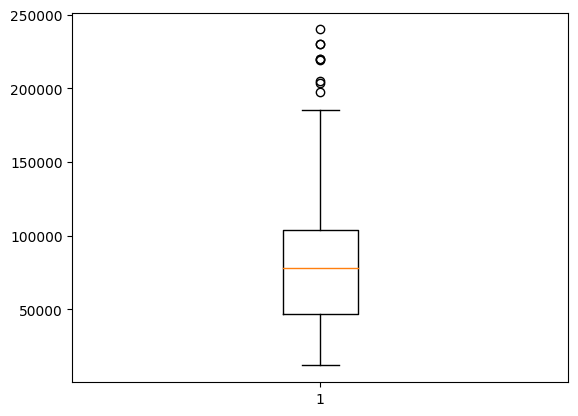

In [ ]:
plt.boxplot(Цена)
plt.show()

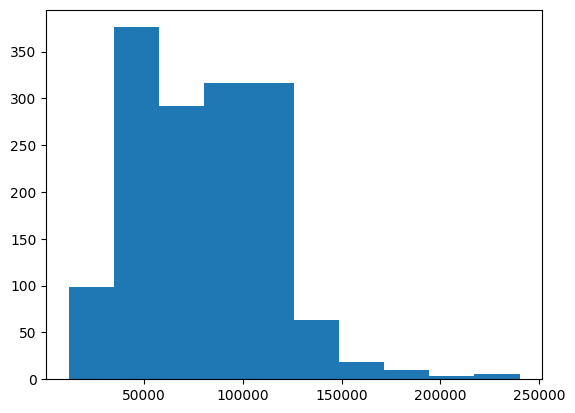

In [ ]:
plt.hist(Цена)
plt.show()

In [ ]:
# Ограничуюсь процентилями для наглядности и исключения выбросов
Цена_1 = dataset[
    (dataset['Цена']>=percentile_10_value)&
    (dataset['Цена']<=percentile_90_value)]['Цена']

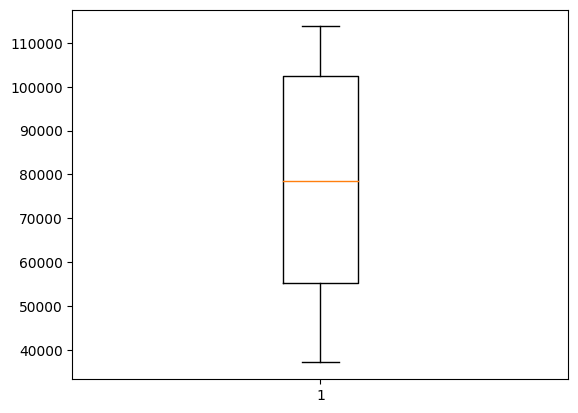

In [ ]:
plt.boxplot(Цена_1)
plt.show()

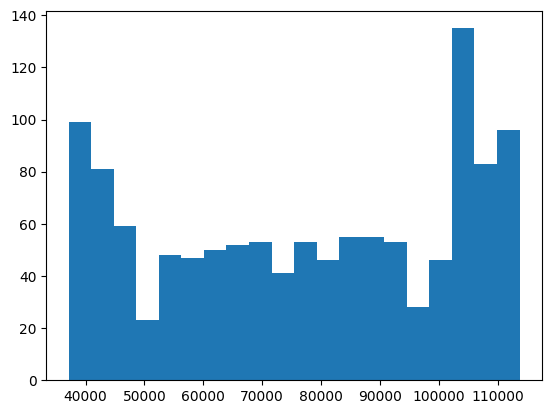

In [ ]:
plt.hist(Цена_1, bins=20)
plt.show()

Ценовая вилка на компьютеры составляет от 12000 рублей до 239992 рублей.
Распределение цены не является нормальным.

Средняя цена компьютера - 79046.0 руб., медианная цена компьютера - 78470.0, т.е. медиана меньше средней на 576.0 руб., это небольшое значение по сравнению со стоимостью компьютера.

*   10-й процентиль цен компьютеров:  37125.0
*   25-й процентиль цен компьютеров:  46843.0
*   50-й процентиль цен компьютеров:  78470.0
*   75-й процентиль цен компьютеров:  103870.0
*   90-й процентиль цен компьютеров:  113740.0

У 10% выборки цены меньше или равны 37125.0 руб., а у 90% - больше этой величины. Четверть компьютеров стоит не менее 46843.0 руб., три четверти - более 46843.0 руб.. Половина компьютеров (медианное значение) стоит 78470.0 руб.. Три четверти компьютеров стоят не менее 103870.0 руб., четверть компьютеров стоят более 103870.0 руб.. 90% компьютеров стоят не менее 113740.0 руб., 10% компьютеров - более 113740.0 руб.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их можно не исключать. Ящик с усами показывает медиану ниже среднего значения, что свидетельствует о наличии небольших выбросов. Гистограмма поразрядно показывает распределение значений, в нашем случае мы наблюдаем, что значения то убывают, то возрастают, площади прямоугольников на гистограмме показывают значения выборки для данного разряда.

In [ ]:
# Сохранию Series ['Продажи'] в переменную Продажи
Продажи = dataset['Продажи']

In [ ]:
max_value = Продажи.max()
min_value = Продажи.min()
print('Больше всего купили: ', max_value, 'Меньше всего купили: ', min_value)

Больше всего купили:  1400 Меньше всего купили:  0


In [ ]:
dataset[dataset['Продажи']==0.0]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
11,50511015,игровой компьютер raskat strike 520,197592,0,intel,2.900,6,DDR4,0.000,16,NaN,SSD 240Gb,nvidia rtx 3070,дискретная,NaN
42,163689989,системный блок игровой aspire tc-1660 (dg.bgze...,74510,0,intel,2.600,6,0,2.666,8,SSD,SSD 512 Гб,nvidia geforce gtx 1650,дискретная,4096 Мб
43,163688880,системный блок игровой aspire tc-1660 (dg.bgze...,65139,0,intel,2.600,6,DDR4,2.666,8,SSD,SSD 512 Гб,nvidia geforce gtx 1650,дискретная,4096 Мб
44,163494489,системный блок lenovo ideacentre 5 gen 6 (90rx...,63632,0,amd,3.800,8,DDR4,3.200,8,SSD,SSD 256 Гб,amd radeon graphics,встроенная,sma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,156273292,игровой компьютер combat m9 white,101520,0,intel,3.700,10,DDR4,3.200,32,SSD; HDD,HDD 1000 гб,nvidia geforce rtx 3060 (8 gb),дискретная,8 Гб
1498,156273291,игровой компьютер combat m9 white,101520,0,intel,3.700,10,DDR4,3.200,32,SSD; HDD,HDD 1000 гб,nvidia geforce rtx 3060 (8 gb),дискретная,8 Гб
1499,160213631,игровой компьютер kreator r4,101268,0,intel,0.231,6,DDR4,3.200,32,SSD; HDD,SSD 512 Гб,nvidia geforce gtx 1660 super (6 gb),дискретная,6144 Мб
1500,153419008,компьютер игровой пк системный блок archer,101097,0,intel,0.000,6,DDR4,0.000,16,SSD,SSD 500 Гб,nvidia rtx 3060,дискретная,12 Гб


Значений с нулевыми продажами очень много - 942 из 1501, возможно, это связано с тем, что такие компьютеры вследствие параллельного импорта появились на рынке недавно и их пока неособенно покупают. Нулевые продажи исключать из анализа не буду.

In [ ]:
mean_value = Продажи.mean()
print('Среднее количество продаж: ', mean_value)

Среднее количество продаж:  7.953364423717522


In [ ]:
median_value = Продажи.median()
print('Медианное количество продаж: ', median_value)

Медианное количество продаж:  0.0


In [ ]:
percentile_10_value = Продажи.quantile(0.10)
percentile_25_value = Продажи.quantile(0.25)
percentile_50_value = Продажи.quantile(0.50)
percentile_75_value = Продажи.quantile(0.75)
percentile_90_value = Продажи.quantile(0.90)
print('10-й процентиль количества продаж: ', percentile_10_value)
print('25-й процентиль количества продаж: ', percentile_25_value)
print('50-й процентиль количества продаж: ', percentile_50_value)
print('75-й процентиль количества продаж: ', percentile_75_value)
print('90-й процентиль количества продаж: ', percentile_90_value)

10-й процентиль количества продаж:  0.0
25-й процентиль количества продаж:  0.0
50-й процентиль количества продаж:  0.0
75-й процентиль количества продаж:  1.0
90-й процентиль количества продаж:  10.0


In [ ]:
# Коэффициент асимметрии
Продажи.skew()

16.172650447104438

In [ ]:
# Коэффициент эксцесса
Продажи.kurtosis()

332.38364290147257

In [ ]:
# Проверка на нормальность
stats.shapiro(Продажи)

ShapiroResult(statistic=0.11621034145355225, pvalue=0.0)

Проскольку pvalue=0.0, распределение не является нормальным.

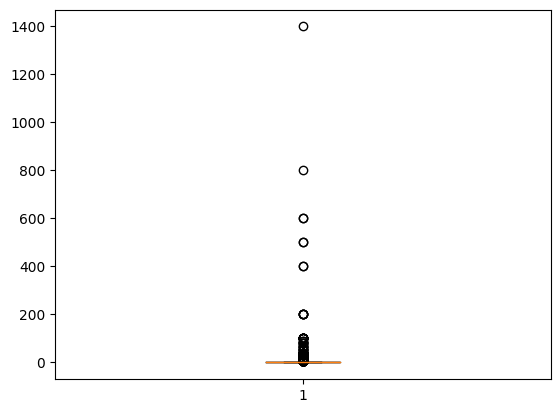

In [ ]:
plt.boxplot(Продажи)
plt.show()

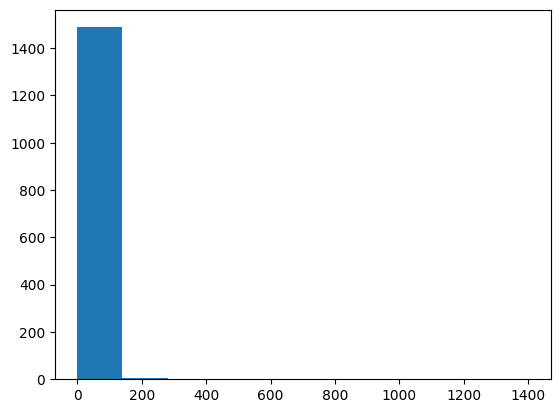

In [ ]:
plt.hist(Продажи)
plt.show()

При значении 75-ого процентиля количества продаж = 1 даже нет смысла ограничиваться процентилями - большинство товаров не покупалось.

Разброс количества продаж огромен - от 0 до 1400, причем нулевые продажи составляют большую часть выборки. Распределение продаж не является нормальным.

Среднее количество продаж - 8, медианное количество продаж - 0, т.е. медиана гораздо меньше средней, что говорит о больших выбросах.

*   10-й процентиль количества продаж:  0
*   25-й процентиль количества продаж:  0
*   50-й процентиль количества продаж:  0
*   75-й процентиль количества продаж:  1
*   90-й процентиль количества продаж:  10

Три четверти компьютеров продавались не менее одного раза, четверть компьютеров продавалась более одного раза. 90% компьютеров продавались не менее 10 раз, 10% компьютеров - более 10 раз.

Графический анализ показывает, что в выборке содержатся большие выбросы, исключать их не нужно. Ящик с усами демонстрирует медиану гораздо ниже среднего значения, что свидетельствует о наличии больших выбросов. Гистограмма также показывает большое количество нулевых продаж.

In [ ]:
# Сохранию Series ['Тактовая частота'] в переменную ТактоваяЧастота
ТактоваяЧастота = dataset['Тактовая частота']

In [ ]:
max_value = ТактоваяЧастота.max()
min_value = ТактоваяЧастота.min()
print('Наибольшая тактовая частота: ', max_value, 'Наименьшая тактовая частота: ', min_value)

Наибольшая тактовая частота:  4.3 Наименьшая тактовая частота:  0.0


In [ ]:
dataset[dataset['Тактовая частота']==0.0]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
1,114454980,мощный игровой компьютер град 2.0 v3,179799,20,0,0.0,0,DDR4,3.000,32,NaN,NaN,NaN,0,NaN
5,21516725,мощный игровой компьютер robotcomp борей v2,102826,80,0,0.0,0,0,0.000,0,SSD M.2 + SSD,HDD 1000 Гб,NaN,0,NaN
6,89119889,игровой компьютер robotcomp аллигатор 3.0 v3,48700,100,0,0.0,0,DDR4,2.666,32,NaN,NaN,amd radeon vega 7,встроенная,выделяется из оперативной памяти
7,21516443,мощный игровой компьютер robotcomp борей v3,110603,40,0,0.0,0,0,0.000,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,154089552,игровой компьютер slasher s2,102460,0,0,0.0,0,0,0.000,0,NaN,NaN,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1461,154089551,игровой компьютер slasher s2,102460,0,0,0.0,0,DDR4,3.200,32,NaN,NaN,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1471,153419185,компьютер игровой пк системный блок legend star,102098,0,intel,0.0,6,DDR4,0.000,32,SSD+HDD,SSD 480 ГБ,nvidia rtx 3050,дискретная,8 Гб
1500,153419008,компьютер игровой пк системный блок archer,101097,0,intel,0.0,6,DDR4,0.000,16,SSD,SSD 500 Гб,nvidia rtx 3060,дискретная,12 Гб


Нулевых значений не очень много, попробую их исключить.

In [ ]:
ТактоваяЧастота = dataset[dataset['Тактовая частота']!=0.0]['Тактовая частота']

In [ ]:
# Снова рассчитаю максимальное и минимальное значения
max_value = ТактоваяЧастота.max()
min_value = ТактоваяЧастота.min()
print('Наибольшая тактовая частота: ', max_value, 'Наименьшая тактовая частота: ', min_value)

Наибольшая тактовая частота:  4.3 Наименьшая тактовая частота:  0.231


In [ ]:
mean_value = ТактоваяЧастота.mean()
print('Средняя тактовая частота: ', mean_value)

Средняя тактовая частота:  3.111070747217806


In [ ]:
median_value = ТактоваяЧастота.median()
print('Медианная тактовая частота: ', median_value)

Медианная тактовая частота:  3.3


In [ ]:
percentile_10_value = ТактоваяЧастота.quantile(0.10)
percentile_25_value = ТактоваяЧастота.quantile(0.25)
percentile_50_value = ТактоваяЧастота.quantile(0.50)
percentile_75_value = ТактоваяЧастота.quantile(0.75)
percentile_90_value = ТактоваяЧастота.quantile(0.90)
print('10-й процентиль тактовых частот: ', percentile_10_value)
print('25-й процентиль тактовых частот: ', percentile_25_value)
print('50-й процентиль тактовых частот: ', percentile_50_value)
print('75-й процентиль тактовых частот: ', percentile_75_value)
print('90-й процентиль тактовых частот: ', percentile_90_value)

10-й процентиль тактовых частот:  2.1
25-й процентиль тактовых частот:  2.5
50-й процентиль тактовых частот:  3.3
75-й процентиль тактовых частот:  3.7
90-й процентиль тактовых частот:  3.7


In [ ]:
ТактоваяЧастота.describe()

count    1258.000000
mean        3.111071
std         0.652435
min         0.231000
25%         2.500000
50%         3.300000
75%         3.700000
max         4.300000
Name: Тактовая частота, dtype: float64

In [ ]:
# Коэффициент асимметрии
ТактоваяЧастота.skew()

-0.8469300543614371

In [ ]:
# Коэффициент эксцесса
ТактоваяЧастота.kurtosis()

1.059341973712053

In [ ]:
# Проверка на нормальность
stats.shapiro(ТактоваяЧастота)

ShapiroResult(statistic=0.8875297904014587, pvalue=2.7246642498387703e-29)

Поскольку pvalue ниже уровня значимости 0.05, распределение не является нормальным.

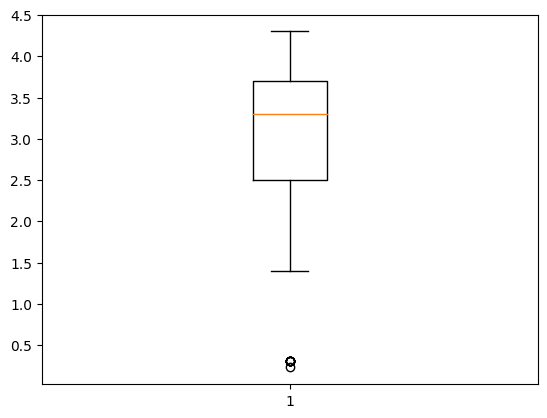

In [ ]:
plt.boxplot(ТактоваяЧастота)
plt.show()

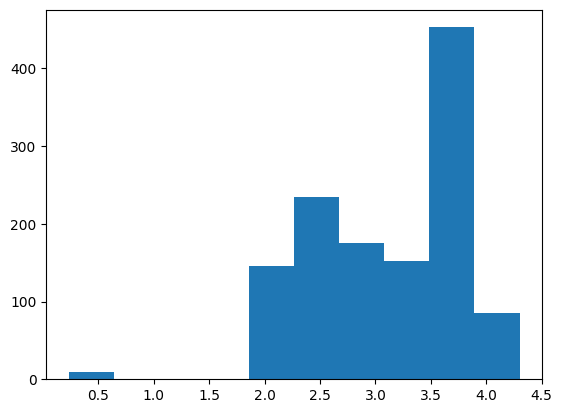

In [ ]:
plt.hist(ТактоваяЧастота)
plt.show()

In [ ]:
# Ограничуюсь процентилями для наглядности и исключения выбросов
ТактоваяЧастота_1 = dataset[
    (dataset['Тактовая частота']>=percentile_10_value)&
    (dataset['Тактовая частота']<=percentile_90_value)]['Тактовая частота']

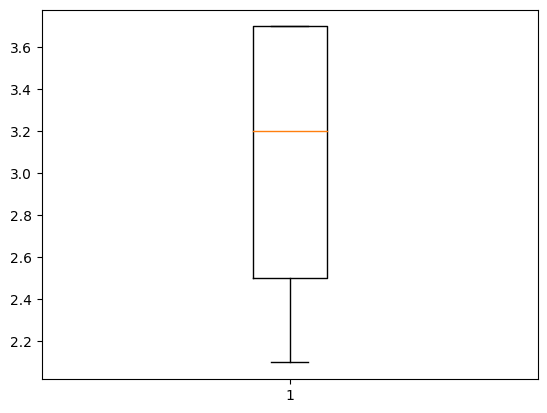

In [ ]:
plt.boxplot(ТактоваяЧастота_1)
plt.show()

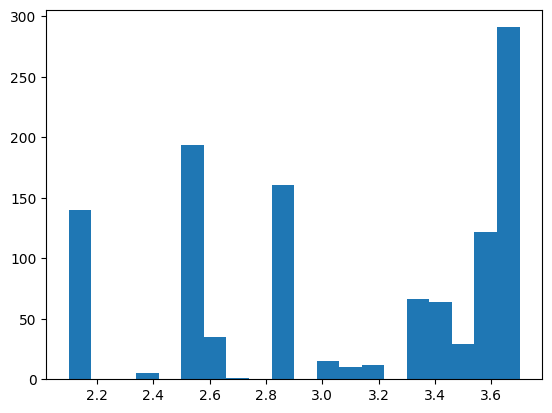

In [ ]:
plt.hist(ТактоваяЧастота_1, bins=20)
plt.show()

Тактовая частота представлена в интервале от 0.231 до 4.3 ГГц. Ее распределение не является нормальным.

Средняя тактовая частота - 3.111 ГГц, медианная тактовая частота - 3.3 ГГц, медиана больше средней, т.е. распределение переменной имеет отрицательную асимметрию.

*   10-й процентиль тактовых частот:  2.1
*   25-й процентиль тактовых частот:  2.5
*   50-й процентиль тактовых частот:  3.3
*   75-й процентиль тактовых частот:  3.7
*   90-й процентиль тактовых частот:  3.7

У 10% выборки тактовые частоты меньше или равны 2.1 ГГц, а у 90% - больше 2.1 ГГц. Четверть тактовых частот составляет не менее 2.5 ГГц, три четверти - более 2.5 ГГц. Половина тактовых частот (медианное значение) составляет 3.3 ГГц. Три четверти тактовых частот составляют не менее 3.7 ГГц, четверть тактовых частот составляет более 3.7 ГГц. 90% тактовых частот также составляют не менее 3.7 ГГц, 10% тактовых частот - более 3.7 ГГц.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их можно исключить.

In [ ]:
# Сохранию Series ['Количество ядер'] в переменную КоличествоЯдер
КоличествоЯдер = dataset['Количество ядер']

In [ ]:
max_value = КоличествоЯдер.max()
min_value = КоличествоЯдер.min()
print('Больше всего ядер: ', max_value, 'Меньше всего ядер: ', min_value)

Больше всего ядер:  18 Меньше всего ядер:  0


In [ ]:
dataset[dataset['Количество ядер']==0.0]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
1,114454980,мощный игровой компьютер град 2.0 v3,179799,20,0,0.0,0,DDR4,3.000,32,NaN,NaN,NaN,0,NaN
5,21516725,мощный игровой компьютер robotcomp борей v2,102826,80,0,0.0,0,0,0.000,0,SSD M.2 + SSD,HDD 1000 Гб,NaN,0,NaN
6,89119889,игровой компьютер robotcomp аллигатор 3.0 v3,48700,100,0,0.0,0,DDR4,2.666,32,NaN,NaN,amd radeon vega 7,встроенная,выделяется из оперативной памяти
7,21516443,мощный игровой компьютер robotcomp борей v3,110603,40,0,0.0,0,0,0.000,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,132190650,игровой компьютер mist x3,102952,0,0,0.0,0,0,0.000,0,NaN,NaN,NaN,0,NaN
1453,154089550,игровой компьютер slasher s2,102460,0,0,0.0,0,0,0.000,0,SSD; HDD,HDD 1000 гб,NaN,0,NaN
1460,154089552,игровой компьютер slasher s2,102460,0,0,0.0,0,0,0.000,0,NaN,NaN,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1461,154089551,игровой компьютер slasher s2,102460,0,0,0.0,0,DDR4,3.200,32,NaN,NaN,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб


Нулевых значений также не очень много, исключу их.

In [ ]:
КоличествоЯдер = dataset[dataset['Количество ядер']!=0.0]['Количество ядер']

In [ ]:
# Снова рассчитаю максимальное и минимальное значения
max_value = КоличествоЯдер.max()
min_value = КоличествоЯдер.min()
print('Больше всего ядер: ', max_value, 'Меньше всего ядер: ', min_value)

Больше всего ядер:  18 Меньше всего ядер:  2


In [ ]:
mean_value = КоличествоЯдер.mean()
print('Среднее количество ядер: ', mean_value)

Среднее количество ядер:  7.248270561106841


In [ ]:
median_value = КоличествоЯдер.median()
print('Медианное количество ядер: ', median_value)

Медианное количество ядер:  6.0


In [ ]:
percentile_10_value = КоличествоЯдер.quantile(0.10)
percentile_25_value = КоличествоЯдер.quantile(0.25)
percentile_50_value = КоличествоЯдер.quantile(0.50)
percentile_75_value = КоличествоЯдер.quantile(0.75)
percentile_90_value = КоличествоЯдер.quantile(0.90)
print('10-й процентиль количества ядер: ', percentile_10_value)
print('25-й процентиль количества ядер: ', percentile_25_value)
print('50-й процентиль количества ядер: ', percentile_50_value)
print('75-й процентиль количества ядер: ', percentile_75_value)
print('90-й процентиль количества ядер: ', percentile_90_value)

10-й процентиль количества ядер:  4.0
25-й процентиль количества ядер:  6.0
50-й процентиль количества ядер:  6.0
75-й процентиль количества ядер:  10.0
90-й процентиль количества ядер:  12.0


In [ ]:
КоличествоЯдер.describe()

count    1301.000000
mean        7.248271
std         3.463747
min         2.000000
25%         6.000000
50%         6.000000
75%        10.000000
max        18.000000
Name: Количество ядер, dtype: float64

In [ ]:
# Коэффициент асимметрии
КоличествоЯдер.skew()

1.1219504698365617

In [ ]:
# Коэффициент эксцесса
КоличествоЯдер.kurtosis()

0.5003230269441166

In [ ]:
# Проверка на нормальность
stats.shapiro(КоличествоЯдер)

ShapiroResult(statistic=0.8196630477905273, pvalue=7.231010020715589e-36)

Поскольку pvalue меньше уровня значимости 0.05, распределение не является нормальным.

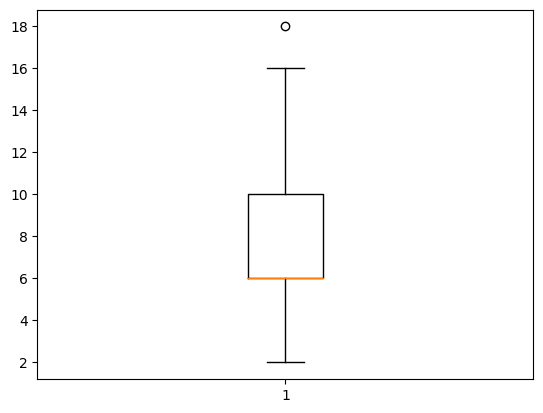

In [ ]:
plt.boxplot(КоличествоЯдер)
plt.show()

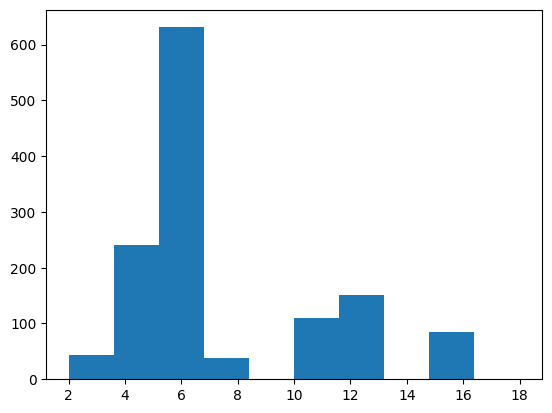

In [ ]:
plt.hist(КоличествоЯдер)
plt.show()

In [ ]:
# Ограничуюсь процентилями для наглядности и исключения выбросов
КоличествоЯдер_1 = dataset[
    (dataset['Количество ядер']>=percentile_10_value)&
    (dataset['Количество ядер']<=percentile_90_value)]['Количество ядер']

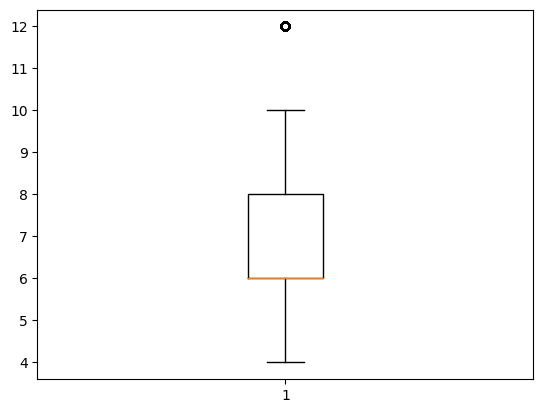

In [ ]:
plt.boxplot(КоличествоЯдер_1)
plt.show()

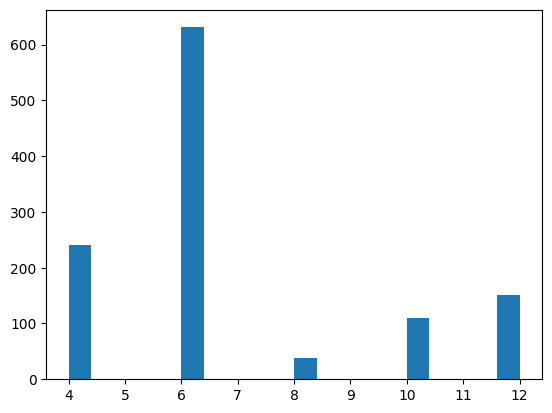

In [ ]:
plt.hist(КоличествоЯдер_1, bins=20)
plt.show()

Количество ядер представлено в интервале от 2 до 18. Его распределение не является нормальным.

Среднее количество ядер - 7.248, медианное количество ядер - 6, медиана меньше средней, т.е. есть выбросы.

*   10-й процентиль количества ядер:  4.0
*   25-й процентиль количества ядер:  6.0
*   50-й процентиль количества ядер:  6.0
*   75-й процентиль количества ядер:  10.0
*   90-й процентиль количества ядер:  12.0

У 10% выборки количество ядер составляет меньше или равно 4, а у 90% - больше 4. Четверть компьютеров имеют не менее 6 ядер, три четверти - более 6. Половина компьютеров (медианное значение) имеет 6 ядер. Три четверти компьютеров имеют не менее 10 ядер, четверть компьютеров имеет более 10 ядер. 90% компьютеров имеют не менее 12 ядер, у 10% компьютеров - более 12 ядер.

Графический анализ показывает, что в выборке содержатся выбросы, их можно оставить.

In [ ]:
# Сохранию Series ['Частота оперативной памяти'] в переменную ЧастотаОП
ЧастотаОП = dataset['Частота оперативной памяти']

In [ ]:
max_value = ЧастотаОП.max()
min_value = ЧастотаОП.min()
print('Наибольшая частота оперативной памяти: ', max_value, 'Наименьшая частота оперативной памяти: ', min_value)

Наибольшая частота оперативной памяти:  5.0 Наименьшая частота оперативной памяти:  0.0


In [ ]:
dataset[dataset['Частота оперативной памяти']==0.0]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
0,152611584,игровой компьютер nagibator amd ryzen 5 5600g ...,46722,100,amd,3.9,6,0,0.0,0,SSD,SSD 1000Гб арт. 152611584,NaN,0,NaN
2,158973060,игровой компьютер intel core i5 12400f rtx3060ti,85199,30,intel,2.9,6,0,0.0,0,SSD; SSD M.2,SSD 1000 Гб,NaN,0,NaN
3,149164230,"игровой компьютер, системный блок intel core i...",24570,40,intel,3.6,4,0,0.0,0,NaN,NaN,NaN,0,NaN
5,21516725,мощный игровой компьютер robotcomp борей v2,102826,80,0,0.0,0,0,0.0,0,SSD M.2 + SSD,HDD 1000 Гб,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,145361077,игровой компьютер b-surface 3,101548,0,intel,2.1,12,DDR4,0.0,32,SSD; HDD,HDD 1000 Гб,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1485,145357952,игровой компьютер b-deep 3,101548,0,intel,2.1,12,DDR4,0.0,32,SSD; HDD,HDD 1000 Гб,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1486,145357949,игровой компьютер b-deep 3,101548,0,intel,2.1,12,DDR4,0.0,32,SSD; HDD,HDD 1000 Гб,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб
1500,153419008,компьютер игровой пк системный блок archer,101097,0,intel,0.0,6,DDR4,0.0,16,SSD,SSD 500 Гб,nvidia rtx 3060,дискретная,12 Гб


Нулевых значений не очень много, исключу их.

In [ ]:
ЧастотаОП = dataset[dataset['Частота оперативной памяти']!=0.0]['Частота оперативной памяти']

In [ ]:
# Снова рассчитаю максимальное и минимальное значения
max_value = ЧастотаОП.max()
min_value = ЧастотаОП.min()
print('Наибольшая частота оперативной памяти: ', max_value, 'Наименьшая частота оперативной памяти: ', min_value)

Наибольшая частота оперативной памяти:  5.0 Наименьшая частота оперативной памяти:  1.6


In [ ]:
mean_value = ЧастотаОП.mean()
print('Средняя частота оперативной памяти: ', mean_value)

Средняя частота оперативной памяти:  2.8976013456686287


In [ ]:
median_value = ЧастотаОП.median()
print('Медианная частота оперативной памяти: ', median_value)

Медианная частота оперативной памяти:  2.666


In [ ]:
percentile_10_value = ЧастотаОП.quantile(0.10)
percentile_25_value = ЧастотаОП.quantile(0.25)
percentile_50_value = ЧастотаОП.quantile(0.50)
percentile_75_value = ЧастотаОП.quantile(0.75)
percentile_90_value = ЧастотаОП.quantile(0.90)
print('10-й процентиль частот оперативной памяти: ', percentile_10_value)
print('25-й процентиль частот оперативной памяти: ', percentile_25_value)
print('50-й процентиль частот оперативной памяти: ', percentile_50_value)
print('75-й процентиль частот оперативной памяти: ', percentile_75_value)
print('90-й процентиль частот оперативной памяти: ', percentile_90_value)

10-й процентиль частот оперативной памяти:  2.666
25-й процентиль частот оперативной памяти:  2.666
50-й процентиль частот оперативной памяти:  2.666
75-й процентиль частот оперативной памяти:  3.2
90-й процентиль частот оперативной памяти:  3.2


In [ ]:
ЧастотаОП.describe()

count    1189.000000
mean        2.897601
std         0.359103
min         1.600000
25%         2.666000
50%         2.666000
75%         3.200000
max         5.000000
Name: Частота оперативной памяти, dtype: float64

In [ ]:
# Коэффициент асимметрии
ЧастотаОП.skew()

1.5030928331706241

In [ ]:
# Коэффициент эксцесса
ЧастотаОП.kurtosis()

10.868536218544419

In [ ]:
# Проверка на нормальность
stats.shapiro(ЧастотаОП)

ShapiroResult(statistic=0.6751051545143127, pvalue=8.04345318522445e-43)

Поскольку pvalue меньше уровня значимости 0.05, распределение не является нормальным.

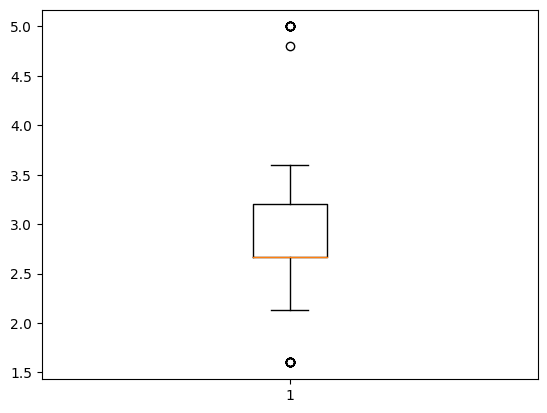

In [ ]:
plt.boxplot(ЧастотаОП)
plt.show()

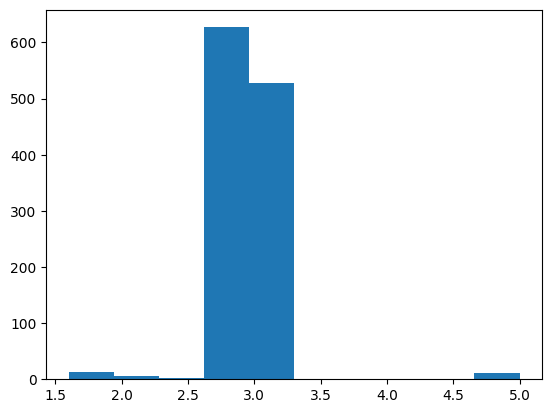

In [ ]:
plt.hist(ЧастотаОП)
plt.show()

In [ ]:
# Ограничуюсь процентилями для наглядности и исключения выбросов
ЧастотаОП_1 = dataset[
    (dataset['Частота оперативной памяти']>=percentile_10_value)&
    (dataset['Частота оперативной памяти']<=percentile_90_value)]['Частота оперативной памяти']

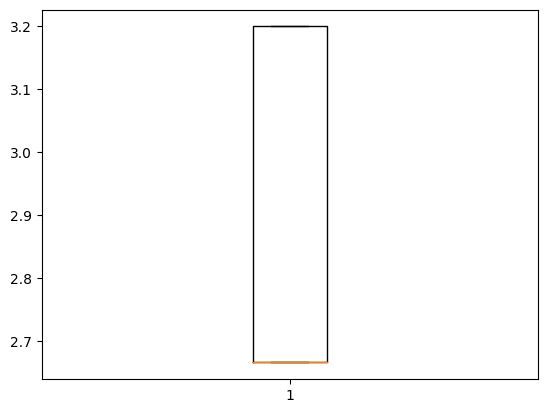

In [ ]:
plt.boxplot(ЧастотаОП_1)
plt.show()

Неудачное решение для ящика с усами.

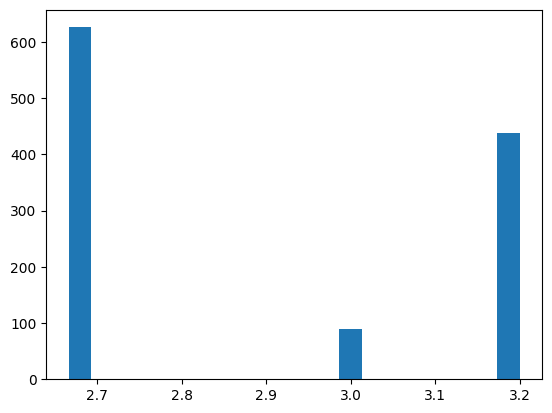

In [ ]:
plt.hist(ЧастотаОП_1, bins=20)
plt.show()

Частота оперативной памяти представлена в интервале от 1.6 до 5 ГГц. Ее распределение не является нормальным.

Средняя частота оперативной памяти - 2.8976 ГГц, медианная частота оперативной памяти - 2.666 ГГц, медиана меньше средней, т.е. есть небольшие выбросы.

*   10-й процентиль частот оперативной памяти:  2.666
*   25-й процентиль частот оперативной памяти:  2.666
*   50-й процентиль частот оперативной памяти:  2.666
*   75-й процентиль частот оперативной памяти:  3.2
*   90-й процентиль частот оперативной памяти:  3.2

У 10% выборки частоты оперативной памяти меньше или равны 2.666 ГГц, а у 90% - больше 2.666 ГГц. Четверть частот оперативной памяти составляет не менее 2.666 ГГц, три четверти - более 2.666 ГГц. Половина частот оперативной памяти (медианное значение) составляет 2.666 ГГц. Три четверти частот оперативной памяти составляют не менее 3.2 ГГц, четверть частот оперативной памяти составляет более 3.2 ГГц. 90% частот оперативной памяти также составляют не менее 3.2 ГГц, 10% частот оперативной памяти - более 3.2 ГГц.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их лучше оставить.

In [ ]:
# Сохранию Series ['Объем оперативной памяти'] в переменную ОбъемОП
ОбъемОП = dataset['Объем оперативной памяти']

In [ ]:
max_value = ОбъемОП.max()
min_value = ОбъемОП.min()
print('Больше всего оперативной памяти: ', max_value, 'Меньше всего оперативной памяти: ', min_value)

Больше всего оперативной памяти:  64 Меньше всего оперативной памяти:  0


In [ ]:
dataset[dataset['Объем оперативной памяти']==0.0]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера
0,152611584,игровой компьютер nagibator amd ryzen 5 5600g ...,46722,100,amd,3.9,6,0,0.0,0,SSD,SSD 1000Гб арт. 152611584,NaN,0,NaN
2,158973060,игровой компьютер intel core i5 12400f rtx3060ti,85199,30,intel,2.9,6,0,0.0,0,SSD; SSD M.2,SSD 1000 Гб,NaN,0,NaN
3,149164230,"игровой компьютер, системный блок intel core i...",24570,40,intel,3.6,4,0,0.0,0,NaN,NaN,NaN,0,NaN
5,21516725,мощный игровой компьютер robotcomp борей v2,102826,80,0,0.0,0,0,0.0,0,SSD M.2 + SSD,HDD 1000 Гб,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1354,154604481,игровой компьютер slasher s6,108100,0,0,0.0,0,0,0.0,0,NaN,NaN,NaN,0,NaN
1452,132190650,игровой компьютер mist x3,102952,0,0,0.0,0,0,0.0,0,NaN,NaN,NaN,0,NaN
1453,154089550,игровой компьютер slasher s2,102460,0,0,0.0,0,0,0.0,0,SSD; HDD,HDD 1000 гб,NaN,0,NaN
1460,154089552,игровой компьютер slasher s2,102460,0,0,0.0,0,0,0.0,0,NaN,NaN,nvidia geforce rtx 3060 (12 gb),дискретная,12 Гб


Нулевых значений не очень много, исключу их.

In [ ]:
ОбъемОП = dataset[dataset['Объем оперативной памяти']!=0.0]['Объем оперативной памяти']

In [ ]:
# Снова рассчитаю максимальное и минимальное значения
max_value = ОбъемОП.max()
min_value = ОбъемОП.min()
print('Больше всего оперативной памяти: ', max_value, 'Меньше всего оперативной памяти: ', min_value)

Больше всего оперативной памяти:  64 Меньше всего оперативной памяти:  4


In [ ]:
mean_value = ОбъемОП.mean()
print('Средний объем оперативной памяти: ', mean_value)

Средний объем оперативной памяти:  23.022970903522204


In [ ]:
median_value = ОбъемОП.median()
print('Медианный объем оперативной памяти: ', median_value)

Медианный объем оперативной памяти:  16.0


In [ ]:
percentile_10_value = ОбъемОП.quantile(0.10)
percentile_25_value = ОбъемОП.quantile(0.25)
percentile_50_value = ОбъемОП.quantile(0.50)
percentile_75_value = ОбъемОП.quantile(0.75)
percentile_90_value = ОбъемОП.quantile(0.90)
print('10-й процентиль объема оперативной памяти: ', percentile_10_value)
print('25-й процентиль объема оперативной памяти: ', percentile_25_value)
print('50-й процентиль объема оперативной памяти: ', percentile_50_value)
print('75-й процентиль объема оперативной памяти: ', percentile_75_value)
print('90-й процентиль объема оперативной памяти: ', percentile_90_value)

10-й процентиль объема оперативной памяти:  16.0
25-й процентиль объема оперативной памяти:  16.0
50-й процентиль объема оперативной памяти:  16.0
75-й процентиль объема оперативной памяти:  32.0
90-й процентиль объема оперативной памяти:  32.0


In [ ]:
ОбъемОП.describe()

count    1306.000000
mean       23.022971
std        10.353496
min         4.000000
25%        16.000000
50%        16.000000
75%        32.000000
max        64.000000
Name: Объем оперативной памяти, dtype: float64

In [ ]:
# Коэффициент асимметрии
ОбъемОП.skew()

0.9508316712410241

In [ ]:
# Коэффициент эксцесса
ОбъемОП.kurtosis()

2.101654570493976

In [ ]:
# Проверка на нормальность
stats.shapiro(ОбъемОП)

ShapiroResult(statistic=0.7599302530288696, pvalue=6.187895797719457e-40)

Поскольку pvalue меньше уровня значимости 0.05, распределение не является нормальным.


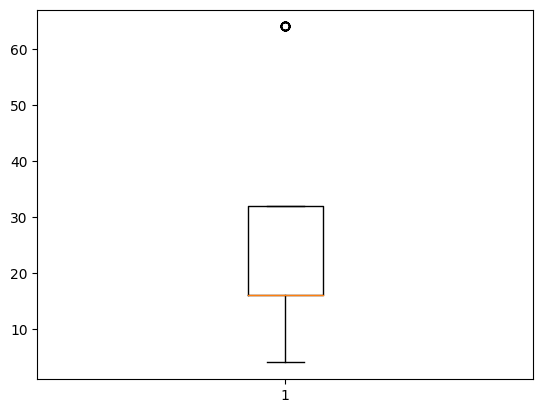

In [ ]:
plt.boxplot(ОбъемОП)
plt.show()

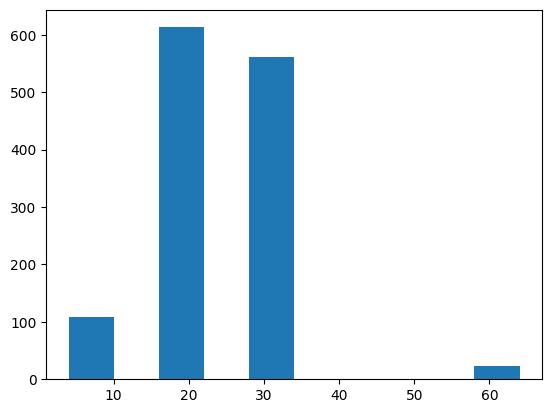

In [ ]:
plt.hist(ОбъемОП)
plt.show()

In [ ]:
# Ограничуюсь процентилями для наглядности и исключения выбросов
ОбъемОП_1 = dataset[
    (dataset['Объем оперативной памяти']>=percentile_10_value)&
    (dataset['Объем оперативной памяти']<=percentile_90_value)]['Объем оперативной памяти']

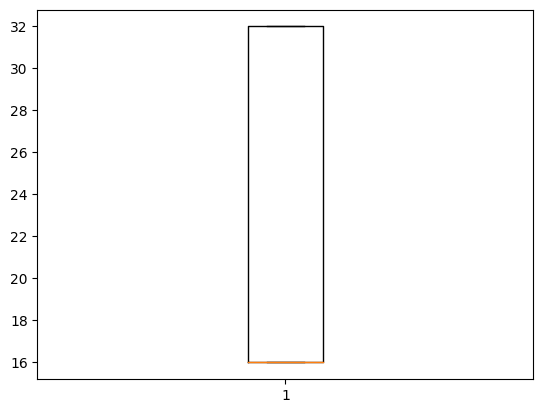

In [ ]:
plt.boxplot(ОбъемОП_1)
plt.show()

Неудачное решение для ящика с усами.

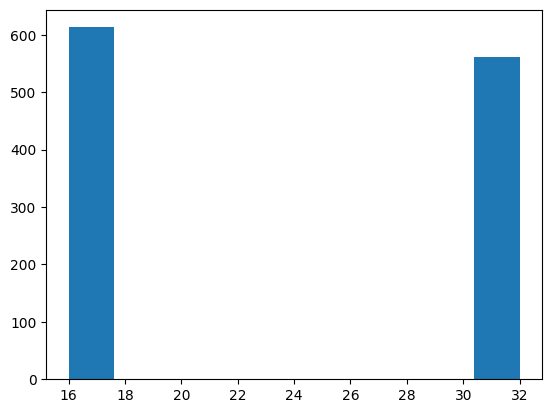

In [ ]:
plt.hist(ОбъемОП_1)
plt.show()

Объем оперативной памяти представлен в интервале от 4 до 64 ГБ. Его распределение не является нормальным.

Средний объем оперативной памяти - 23 ГБ, медианный объем оперативой памяти - 16 ГБ, медиана меньше средней, т.е. есть выбросы.

*   10-й процентиль объема оперативной памяти:  16.0
*   25-й процентиль объема оперативной памяти:  16.0
*   50-й процентиль объема оперативной памяти:  16.0
*   75-й процентиль объема оперативной памяти:  32.0
*   90-й процентиль объема оперативной памяти:  32.0

У 10% выборки объем оперативной памяти составляет меньше или равно 16 ГБ, а у 90% - больше 16 ГБ. Четверть компьютеров имеют не менее 16 ГБ оперативной памяти, три четверти - более 16. Половина компьютеров (медианное значение) имеет 16 ГБ оперативной памяти. Три четверти компьютеров имеют не менее 32 ГБ оперативной памяти, четверть компьютеров имеет более 32 ГБ оперативной памяти. 90% компьютеров имеют не менее 32 ГБ оперативной памяти, у 10% компьютеров - более 32 ГБ оперативной памяти.

Графический анализ показывает, что в выборке содержатся выбросы, их нужно оставить.

**Анализ взаимосвязи числовых признаков**

In [ ]:
columns = ['Цена', 'Продажи', 'Тактовая частота', 'Количество ядер', 'Частота оперативной памяти', 'Объем оперативной памяти']

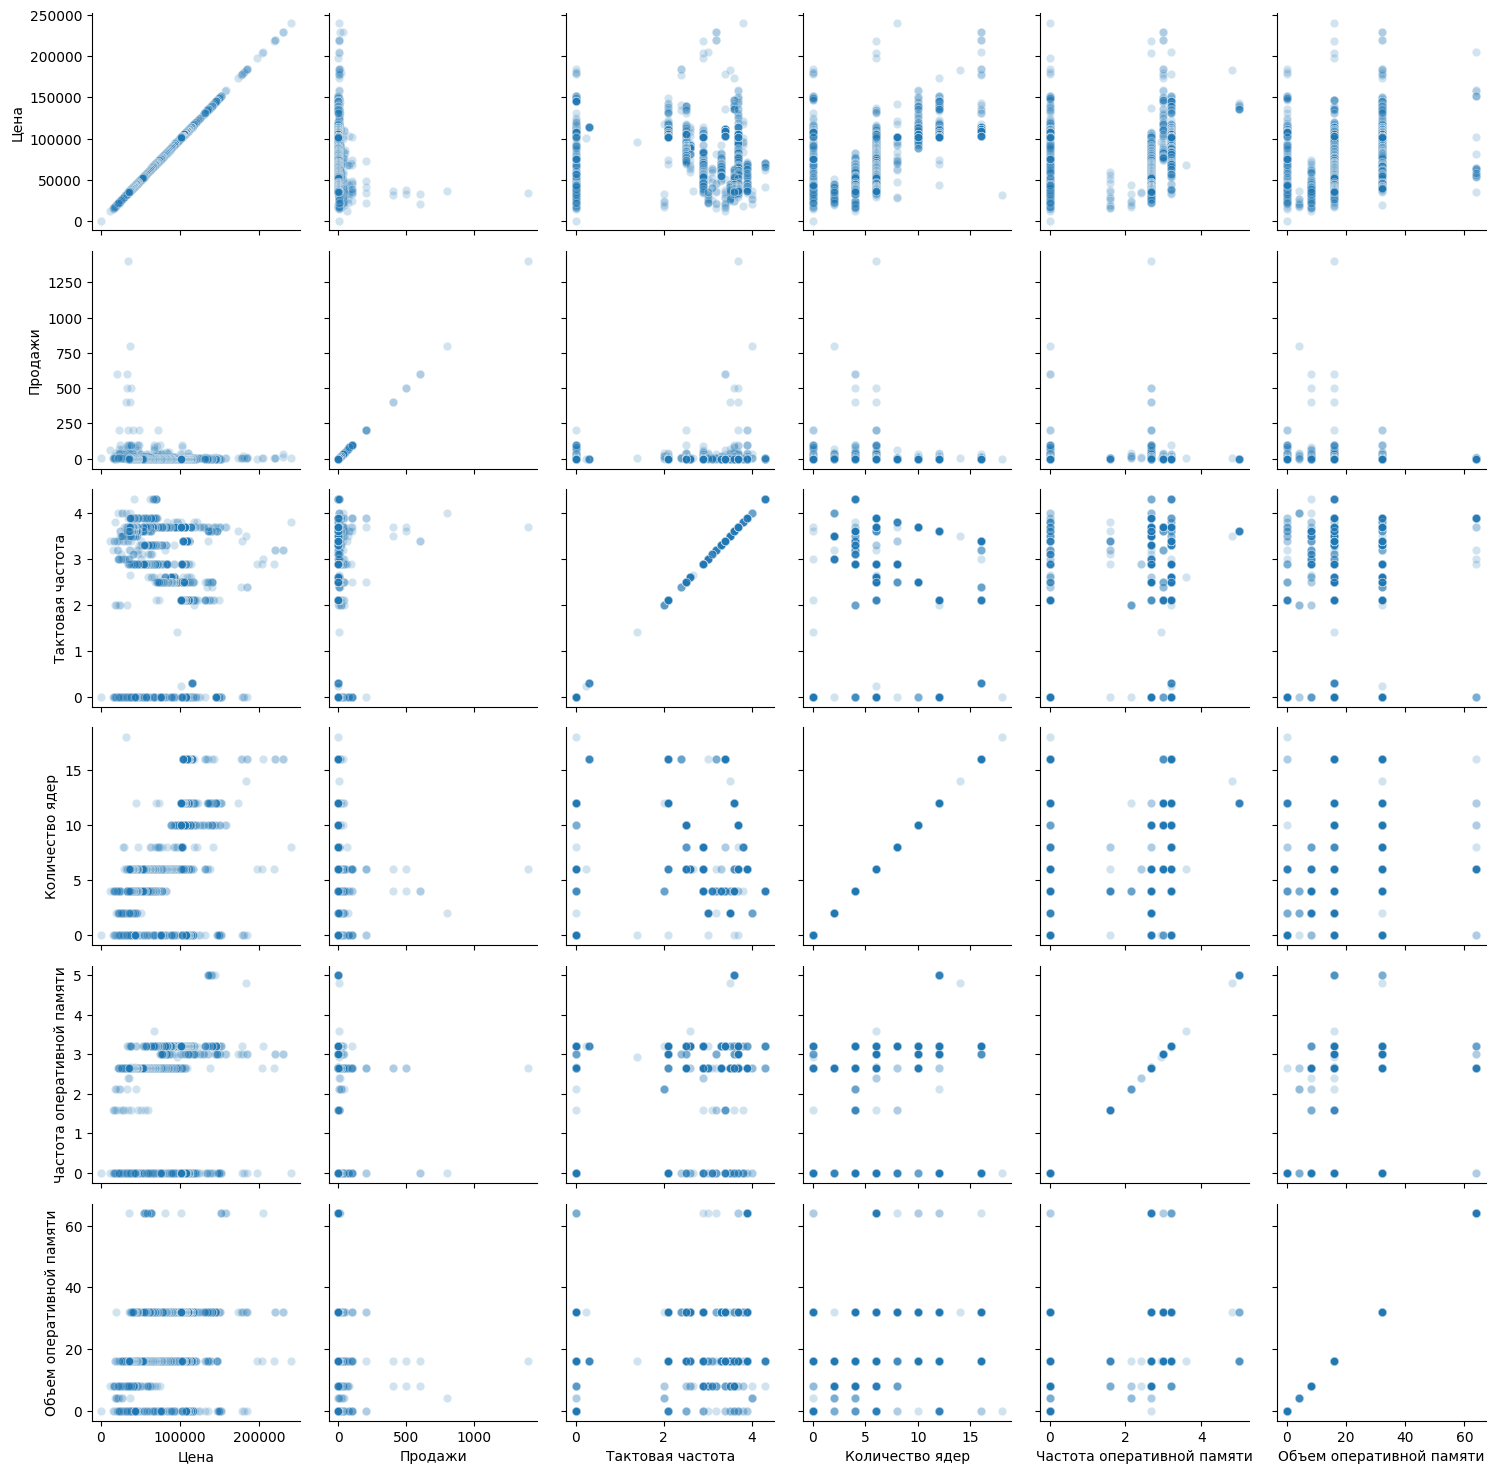

In [ ]:
g = sns.PairGrid(dataset[columns])
g.map(sns.scatterplot, alpha=.2)

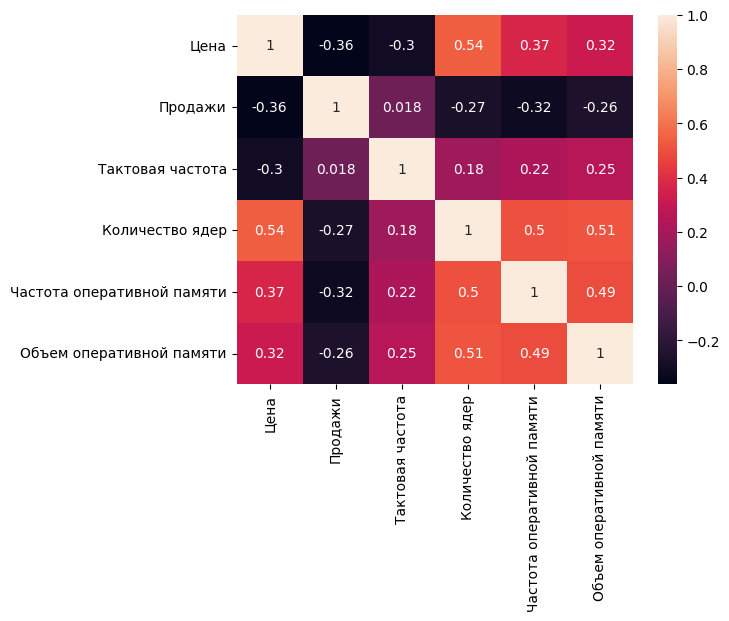

In [ ]:
hm = sns.heatmap(dataset[columns].corr(method = 'spearman'),annot=True)

In [ ]:
for i in columns:
  for j in columns:
    if i!=j:
      if scipy.stats.spearmanr(dataset[i],dataset[j])[1]>=0.05:
        print(i,j,'Незначимая корреляционная связь')

Продажи Тактовая частота Незначимая корреляционная связь
Тактовая частота Продажи Незначимая корреляционная связь


Можно предположить, что
1. чем выше количество ядер процессора, тем выше цена;
2. связь цены с частотой и объемом оперативной памяти заметна;
3. цена не зависит от количества продаж и тактовой частоты процессора, скорее, наоборот, нужно исследовать, зависят ли продажи и тактовая частота процессора от цены ПК;
4. статистически значимая связь между количеством продаж и ценой, количеством ядер, частотой и объемом оперативной памяти отсутствует;
5. связь между продажами и тактовой частотой статистически незначима на уровне значимости 0.05.

**Анализ категориальных признаков**

In [ ]:
dataset['Процессор'].describe()

count      1501
unique        3
top       intel
freq        961
Name: Процессор, dtype: object

In [ ]:
dataset['Процессор'].unique()

array(['amd', '0', 'intel'], dtype=object)

In [ ]:
dataset['Процессор'].value_counts()

intel    961
amd      345
0        195
Name: Процессор, dtype: int64

In [ ]:
Процессор_counts = dataset['Процессор'].value_counts().sort_values(ascending=True)

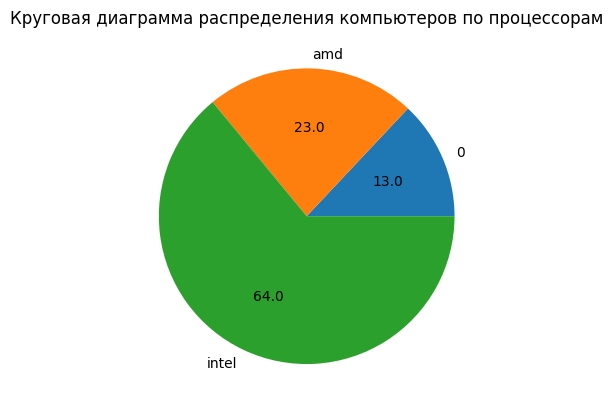

In [ ]:
plt.pie(Процессор_counts.values, labels = Процессор_counts.index, autopct='%.1f')
plt.title('Круговая диаграмма распределения компьютеров по процессорам')
plt.show()

Уникальных значений признака 'Процессор' три: Intel, AMD и не указано.
Наиболее часто встречаемое значение признака - Intel, встретилось 961 раз.
AMD встречается 345 раз. Процессор не указан в 195 случаях.
Круговая диаграмма показывает распределение копьютеров по процессорам с наименованиями процессоров и их процентыми долями:
Intel         - 64%,
AMD           - 23%,
не указано    - 13%.

In [ ]:
dataset['Тип оперативной памяти'].describe()

count     1501
unique       4
top       DDR4
freq      1274
Name: Тип оперативной памяти, dtype: object

In [ ]:
dataset['Тип оперативной памяти'].unique()

array(['0', 'DDR4', 'DDR3', 'DDR5'], dtype=object)

In [ ]:
dataset['Тип оперативной памяти'].value_counts()

DDR4    1274
0        202
DDR3      24
DDR5       1
Name: Тип оперативной памяти, dtype: int64

In [ ]:
ТипОП_counts = dataset['Тип оперативной памяти'].value_counts().sort_values(ascending=True)

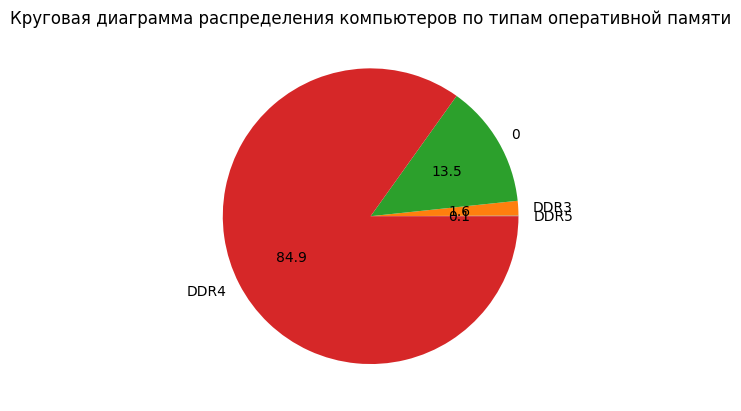

In [ ]:
plt.pie(ТипОП_counts.values, labels = ТипОП_counts.index, autopct='%.1f')
plt.title('Круговая диаграмма распределения компьютеров по типам оперативной памяти')
plt.show()

Уникальных значений признака 'Тип оперативной памяти' четыре:
* DDR4          - встречается 1274 раза,
* не указано    - встречается 202 раза,
* DDR3          - встречается 24 раза,
* DDR5          - встречается 1 раз.

Круговая диаграмма показывает распределение копьютеров по типам оперативной памяти с наименованиями типов оперативной памяти и их процентыми долями:
* DDR4          - 84.9%,
* не указано    - 13.5%,
* DDR3          - 1.5%,
* DDR5          - 0.1%.

In [ ]:
dataset['Тип видеокарты'].describe()

count           1501
unique             4
top       дискретная
freq            1085
Name: Тип видеокарты, dtype: object

In [ ]:
dataset['Тип видеокарты'].unique()

array(['0', 'встроенная', 'дискретная', 'дискретная+встроенная'],
      dtype=object)

In [ ]:
dataset['Тип видеокарты'].value_counts()

дискретная               1085
встроенная                208
0                         205
дискретная+встроенная       3
Name: Тип видеокарты, dtype: int64

In [ ]:
ТипВидеокарты_counts = dataset['Тип видеокарты'].value_counts().sort_values(ascending=True)

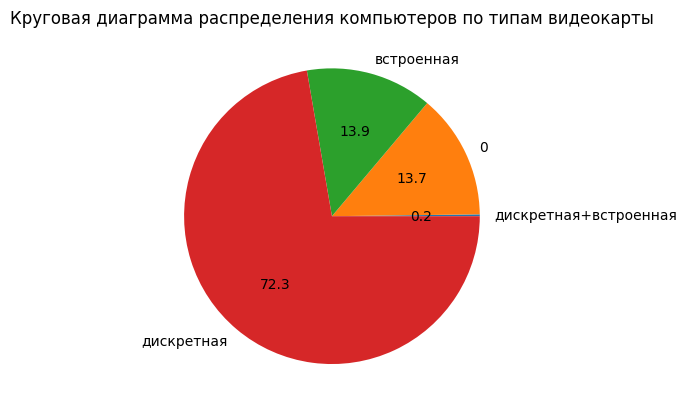

In [ ]:
plt.pie(ТипВидеокарты_counts.values, labels = ТипВидеокарты_counts.index, autopct='%.1f')
plt.title('Круговая диаграмма распределения компьютеров по типам видеокарты')
plt.show()

Уникальных значений признака 'Тип видеокарты' четыре:
* дискретная            - встречается 1085 раз,
* встроенная            - встречается 208 раз,
* не указано            - встречается 205 раз,
* дискретная+встроенная - встречается 3 раза.

Круговая диаграмма показывает распределение компьютеров по типам видеокарты с наименованиями типов видеокарты и их процентыми долями:
* дискретная            - 72.3%,
* встроенная            - 13.9%,
* не указано            - 13.7%,
* дискретная+встроенная - 0.1%.

**Анализ взаимосвязи числовых и категориальных признаков**

**Гипотеза H0**: статистически значимые отличия в группах "Процессор" / "Тип оперативной памяти" / "Тип видеокарты" отсутствуют

In [ ]:
dataset['Процессор'].value_counts()

intel    961
amd      345
0        195
Name: Процессор, dtype: int64

In [ ]:
dataset.groupby('Процессор')['Цена'].mean()

Процессор
0        81421.153846
amd      57198.463768
intel    86325.243496
Name: Цена, dtype: float64

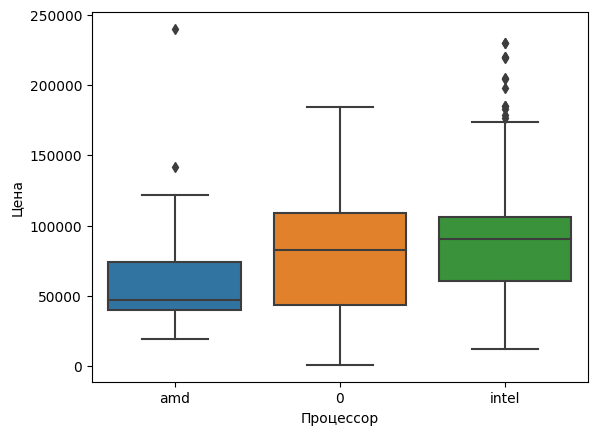

In [ ]:
sns.boxplot(x='Процессор', y='Цена', data=dataset)
plt.show()

In [ ]:
for i in dataset['Процессор'].unique():
  print(i,stats.shapiro(dataset[dataset['Процессор']==i]['Цена'].dropna())[1])

amd 1.1459474332689947e-16
0 3.084212039539125e-06
intel 7.186449447137665e-15


In [ ]:
# Применю непараметрический критерий сравнения групп
d1=dataset[dataset['Процессор']=='intel']['Цена']
d2=dataset[dataset['Процессор']=='amd']['Цена']
scipy.stats.mannwhitneyu(d1,d2)

MannwhitneyuResult(statistic=254917.0, pvalue=8.728185167393294e-50)

Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. производитель процессора оказывает влияние на цену компьютера.

In [ ]:
dataset['Тип оперативной памяти'].value_counts()

DDR4    1274
0        202
DDR3      24
DDR5       1
Name: Тип оперативной памяти, dtype: int64

In [ ]:
dataset.groupby('Тип оперативной памяти')['Цена'].mean()

Тип оперативной памяти
0        79783.688119
DDR3     27865.500000
DDR4     79749.432496
DDR5    183300.000000
Name: Цена, dtype: float64

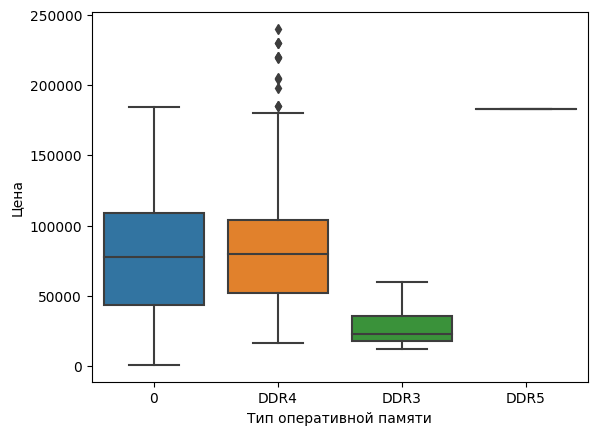

In [ ]:
sns.boxplot(x='Тип оперативной памяти', y='Цена', data=dataset)
plt.show()

In [ ]:
# Помимо неуказанных значений, исключу из анализа DDR5 (1 значение)
for i in dataset[dataset['Тип оперативной памяти']!='DDR5']['Тип оперативной памяти'].unique():
  print(i,stats.shapiro(dataset[dataset['Тип оперативной памяти']==i]['Цена'].dropna())[1])

0 1.2562260280901683e-06
DDR4 1.6870844578269104e-20
DDR3 0.00847675558179617


In [ ]:
# Применю непараметрический критерий сравнения групп
d1=dataset[dataset['Тип оперативной памяти']=='DDR4']['Цена']
d2=dataset[dataset['Тип оперативной памяти']=='DDR3']['Цена']
scipy.stats.mannwhitneyu(d1,d2)

MannwhitneyuResult(statistic=28880.0, pvalue=7.966953451394155e-14)

Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. тип оперативной памяти оказывает влияние на цену компьютера.



In [ ]:
dataset['Тип видеокарты'].value_counts()

дискретная               1085
встроенная                208
0                         205
дискретная+встроенная       3
Name: Тип видеокарты, dtype: int64

In [ ]:
dataset.groupby('Тип видеокарты')['Цена'].mean()

Тип видеокарты
0                        79878.214634
встроенная               40456.524038
дискретная               86306.993548
дискретная+встроенная    45358.333333
Name: Цена, dtype: float64

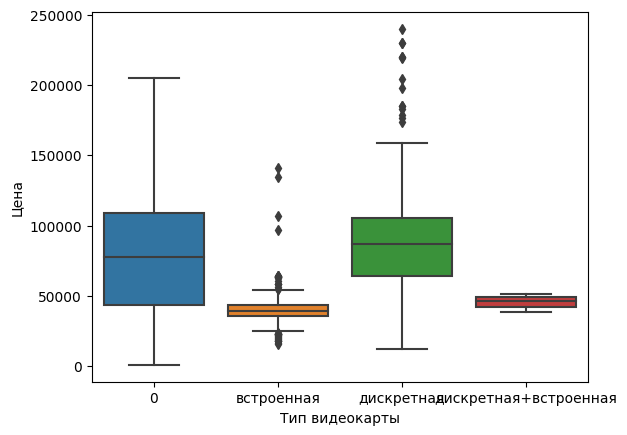

In [ ]:
sns.boxplot(x='Тип видеокарты', y='Цена', data=dataset)
plt.show()

In [ ]:
# Помимо неуказанных значений, исключу из анализа "дискретная+встроенная" (3 значения)
for i in dataset[dataset['Тип видеокарты']!='дискретная+встроенная']['Тип видеокарты'].unique():
  print(i,stats.shapiro(dataset[dataset['Тип видеокарты']==i]['Цена'].dropna())[1])

0 1.1089056215496385e-06
встроенная 3.1090751715420776e-18
дискретная 2.4335446826156936e-17


Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. тип видеокарты оказывает влияние на цену компьютера.

Таким образом, на цену компьютера оказывают влияние производитель процессора, тип оперативной памяти и тип видеокарты.

In [ ]:
# Отфильтрую датасет по столбцу с продажами и оставлю только проданные товары, чтобы найти самые популярные товары
len(dataset[dataset.Продажи!=0])/len(dataset)*100

37.241838774150565

In [ ]:
dataset_Продажи = dataset[dataset.Продажи!=0]
dataset_Продажи.shape

(559, 15)

In [ ]:
dataset_Продажи.Продажи.describe()

count     559.000000
mean       21.355993
std        88.480301
min         1.000000
25%         1.000000
50%         1.000000
75%        10.000000
max      1400.000000
Name: Продажи, dtype: float64

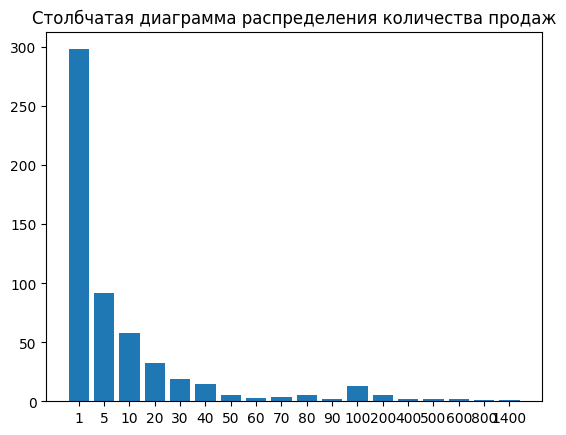

In [ ]:
Продажи = dataset_Продажи.Продажи.value_counts().sort_index()
plt.bar([str(x) for x in Продажи.index], Продажи.values)
plt.title('Столбчатая диаграмма распределения количества продаж')
plt.show()

In [ ]:
np.percentile(dataset_Продажи.Продажи,95)

81.00000000000023

In [ ]:
dataset_Продажи.Цена.describe()

count       559.000000
mean      66609.778175
std       39325.497655
min         750.000000
25%       38558.500000
50%       54139.000000
75%       86736.000000
max      239992.000000
Name: Цена, dtype: float64

In [ ]:
# Уберу строку с "компьютером" за 750 рублей
dataset_Продажи = dataset_Продажи[dataset_Продажи.Цена!=750]

In [ ]:
dataset_Продажи.shape

(558, 15)

In [ ]:
dataset_Продажи.Цена.describe()

count       558.000000
mean      66727.806452
std       39261.558936
min       12000.000000
25%       38606.000000
50%       54139.000000
75%       86803.500000
max      239992.000000
Name: Цена, dtype: float64

In [ ]:
dataset_Продажи.Продажи.describe()

count     558.000000
mean       21.392473
std        88.555484
min         1.000000
25%         1.000000
50%         1.000000
75%        10.000000
max      1400.000000
Name: Продажи, dtype: float64

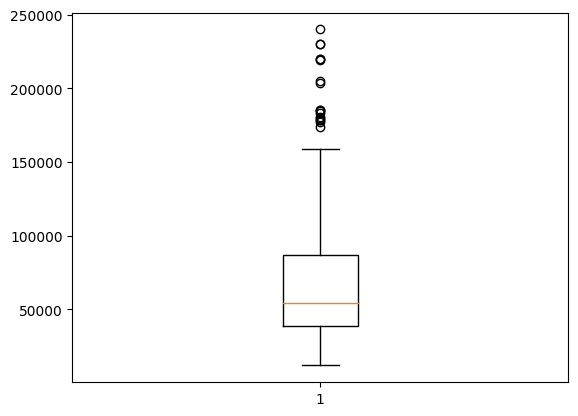

In [ ]:
plt.boxplot(dataset_Продажи.Цена)
plt.show()

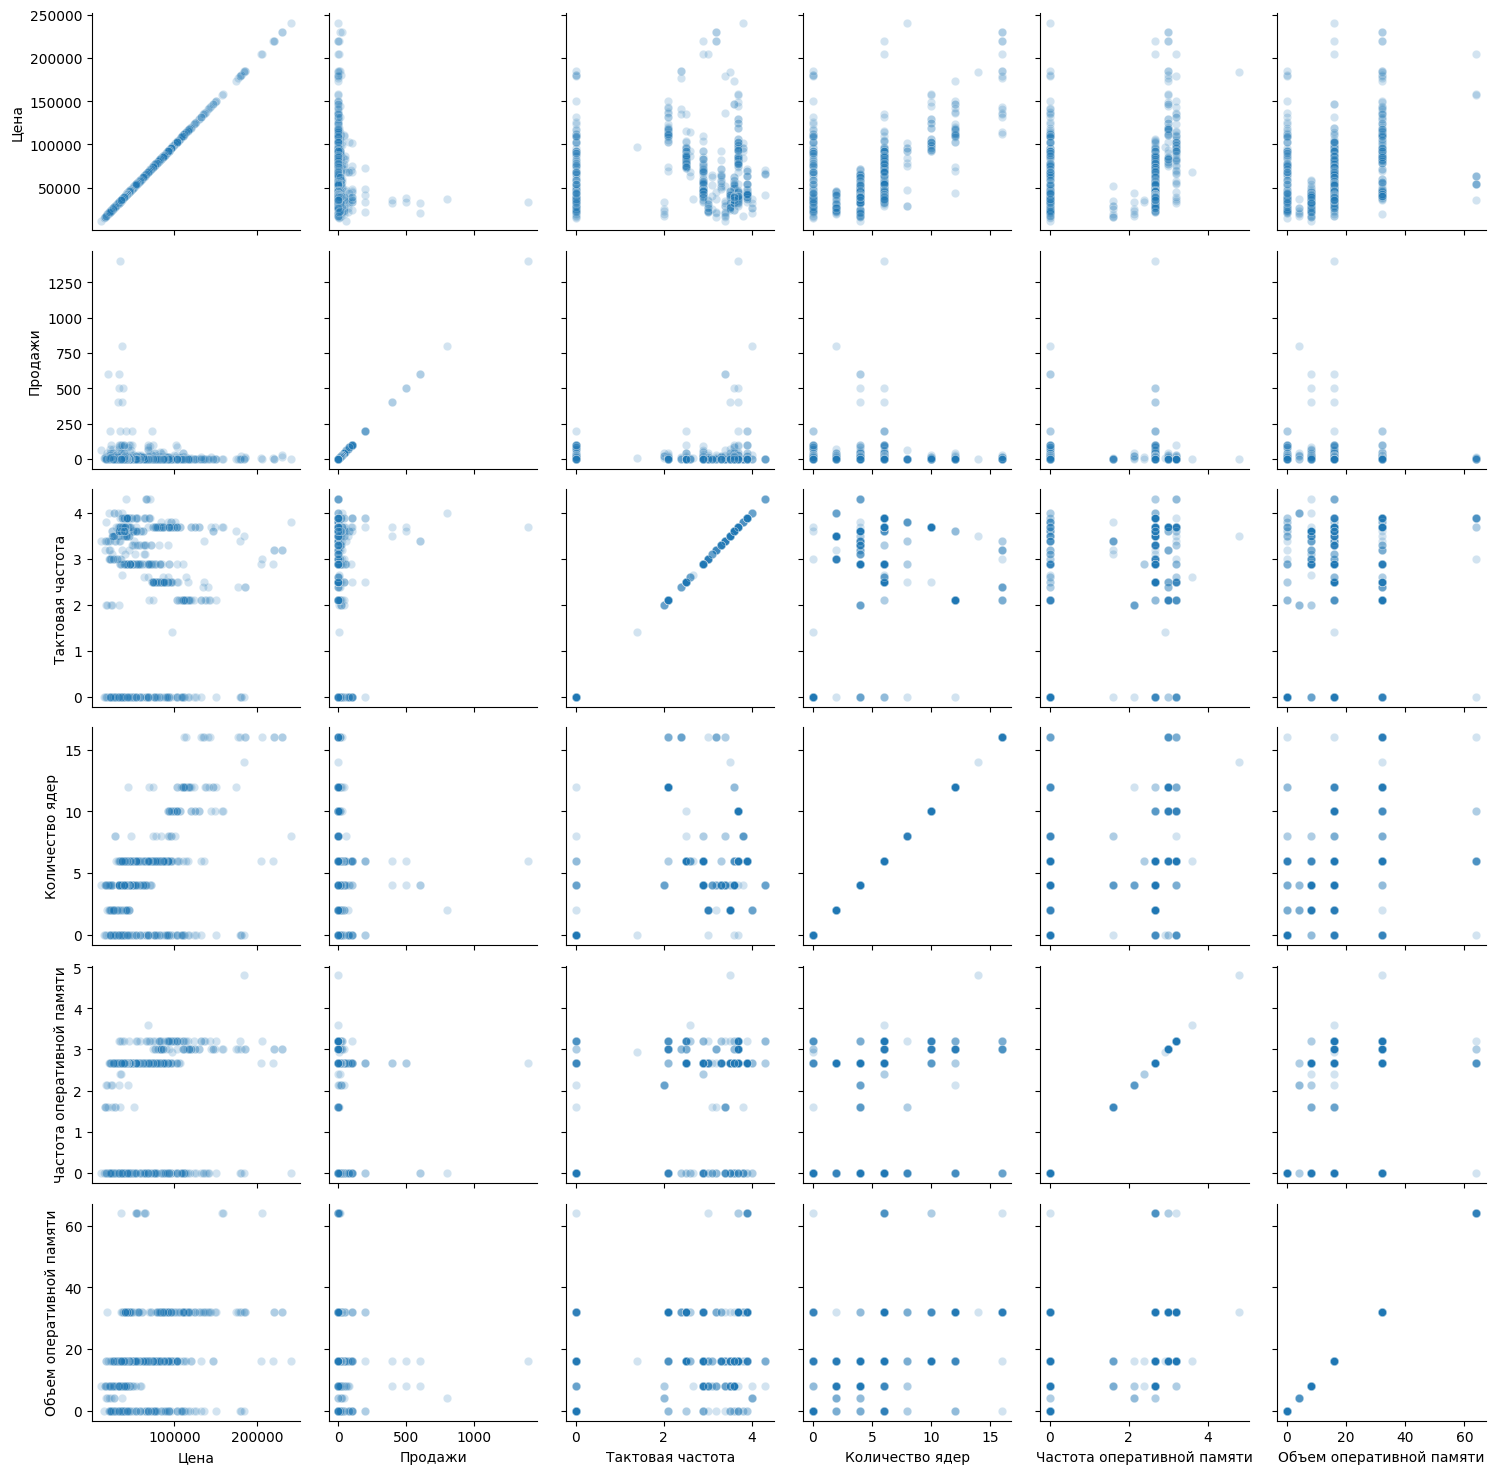

In [ ]:
g = sns.PairGrid(dataset_Продажи[columns])
g.map(sns.scatterplot, alpha=.2)

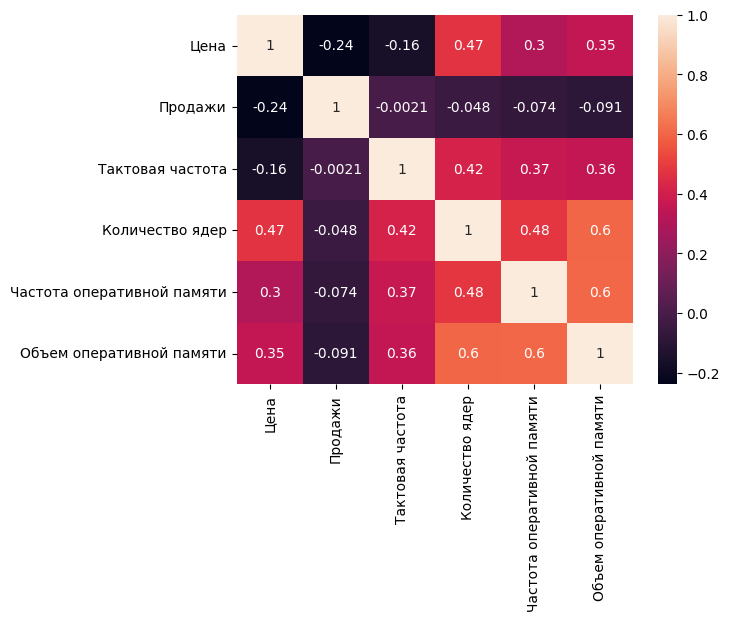

In [ ]:
hm = sns.heatmap(dataset_Продажи[columns].corr(method = 'spearman'),annot=True)

In [ ]:
for i in columns:
  for j in columns:
    if i!=j:
      if scipy.stats.spearmanr(dataset_Продажи[i],dataset_Продажи[j])[1]>=0.05:
        print(i,j,'Незначимая корреляционная связь')

Продажи Тактовая частота Незначимая корреляционная связь
Продажи Количество ядер Незначимая корреляционная связь
Продажи Частота оперативной памяти Незначимая корреляционная связь
Тактовая частота Продажи Незначимая корреляционная связь
Количество ядер Продажи Незначимая корреляционная связь
Частота оперативной памяти Продажи Незначимая корреляционная связь


* У наиболее популярных товаров связь между признаками и количеством продаж слабая, часто отсутствует.
* Связь статистически незначима между количеством продаж и тактовой частотой, количеством ядер, частотой оперативной памяти.
* Чем меньше цена, тем больше продажи (связь отрицательно направленная).

**Анализ взаимосвязи категориальных признаков**

In [ ]:
WD=pd.crosstab(dataset_Продажи['Продажи'],dataset_Продажи['Процессор']); WD

Процессор,0,amd,intel
Продажи,,,
1,60,79,158
5,14,23,55
10,9,16,33
20,6,9,17
...,...,...,...
500,0,1,1
600,0,0,2
800,0,0,1
1400,0,1,0


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 44.286895774700845
degrees of freedom: 34
p-value: 0.11139234858741304



In [ ]:
dataset_Продажи.Продажи.describe()

count     558.000000
mean       21.392473
std        88.555484
min         1.000000
25%         1.000000
50%         1.000000
75%        10.000000
max      1400.000000
Name: Продажи, dtype: float64

In [ ]:
dataset_Продажи.loc[dataset_Продажи[dataset_Продажи.Продажи<=np.percentile(dataset_Продажи.Продажи,50)].index,'sales_category']=1
dataset_Продажи.loc[dataset_Продажи[(dataset_Продажи.Продажи>np.percentile(dataset_Продажи.Продажи,50))&(dataset_Продажи.Продажи<np.percentile(dataset_Продажи.Продажи,75))].index,'sales_category']=2
dataset_Продажи.loc[dataset_Продажи[dataset_Продажи.Продажи>=np.percentile(dataset_Продажи.Продажи,75)].index,'sales_category']=3

In [ ]:
dataset_Продажи.sales_category.value_counts()

1.0    297
3.0    169
2.0     92
Name: sales_category, dtype: int64

In [ ]:
WD=pd.crosstab(dataset_Продажи['sales_category'],dataset_Продажи['Процессор']); WD

Процессор,0,amd,intel
sales_category,,,
1.0,60,79,158
2.0,14,23,55
3.0,31,51,87


In [ ]:
WD=pd.crosstab(dataset_Продажи[dataset_Продажи['Процессор']!='0']['sales_category'],dataset_Продажи[dataset_Продажи['Процессор']!='0']['Процессор']); WD

Процессор,amd,intel
sales_category,,
1.0,79,158
2.0,23,55
3.0,51,87


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 1.2863072988392688
degrees of freedom: 2
p-value: 0.5256321479364012



Связь между количеством продаж и производителем процессора является статистически незначимой на уровне значимости 0.05, т.е. количество продаж не зависит от производителя процессора.

In [ ]:
WD=pd.crosstab(dataset_Продажи['Продажи'],dataset_Продажи['Тип оперативной памяти']); WD

Тип оперативной памяти,0,DDR3,DDR4,DDR5
Продажи,,,,
1,69,10,217,1
5,12,3,77,0
10,11,0,47,0
20,5,0,27,0
...,...,...,...,...
500,0,0,2,0
600,0,2,0,0
800,0,0,1,0
1400,0,0,1,0


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 119.68880207008806
degrees of freedom: 51
p-value: 1.8985877745961632e-07



In [ ]:
WD=pd.crosstab(dataset_Продажи[(dataset_Продажи['Тип оперативной памяти']!='0')&(dataset_Продажи['Тип оперативной памяти']!='DDR5')]['sales_category'],
               dataset_Продажи[(dataset_Продажи['Тип оперативной памяти']!='0')&(dataset_Продажи['Тип оперативной памяти']!='DDR5')]['Тип оперативной памяти']); WD

Тип оперативной памяти,DDR3,DDR4
sales_category,,
1.0,10,217
2.0,3,77
3.0,6,130


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 0.06908902316783301
degrees of freedom: 2
p-value: 0.9660453385213209



Связь между количеством продаж и типом оперативной памяти является статистически незначимой на уровне значимости 0.05, т.е. количество продаж не зависит от типа оперативной памяти.

In [ ]:
WD=pd.crosstab(dataset_Продажи['Продажи'],dataset_Продажи['Тип видеокарты']); WD

Тип видеокарты,0,встроенная,дискретная,дискретная+встроенная
Продажи,,,,
1,65,51,180,1
5,17,21,54,0
10,10,13,35,0
20,10,9,13,0
...,...,...,...,...
500,0,1,1,0
600,1,0,1,0
800,0,1,0,0
1400,0,1,0,0


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 49.2547654857098
degrees of freedom: 51
p-value: 0.5432222707815465



In [ ]:
WD=pd.crosstab(dataset_Продажи[(dataset_Продажи['Тип видеокарты']!='0')&(dataset_Продажи['Тип видеокарты']!='дискретная+встроенная')]['sales_category'],
               dataset_Продажи[(dataset_Продажи['Тип видеокарты']!='0')&(dataset_Продажи['Тип видеокарты']!='дискретная+встроенная')]['Тип видеокарты']); WD

Тип видеокарты,встроенная,дискретная
sales_category,,
1.0,51,180
2.0,21,54
3.0,49,83


In [ ]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(WD)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 9.513893716888735
degrees of freedom: 2
p-value: 0.008591801379066465



Связь между количеством продаж и типом видеокарты является статистически значимой на уровне значимости 0.05, т.е. количество продаж так или иначе зависит от типа видеокарты.

**Анализ популярных технических характеристик**

Рассмотрю 5% товаров с количеством продаж более 81.

In [ ]:
dataset_Продажи_5 = dataset_Продажи[dataset_Продажи.Продажи > np.percentile(dataset_Продажи.Продажи,95)]
dataset_Продажи_5.shape

(28, 16)

In [ ]:
data = dataset_Продажи_5.groupby('Процессор')['Продажи'].count()
data

Процессор
0         6
amd      13
intel     9
Name: Продажи, dtype: int64

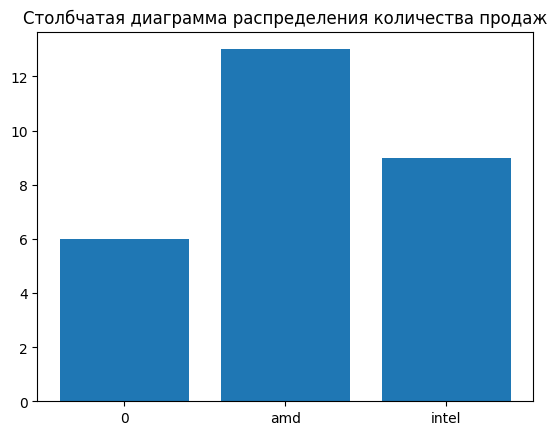

In [ ]:
plt.bar(data.index, data.values)
plt.title('Столбчатая диаграмма распределения количества продаж')
plt.show()

Самый популярный процессор - AMD.

In [ ]:
dataset_Продажи_5['Процессор'].value_counts()

amd      13
intel     9
0         6
Name: Процессор, dtype: int64

In [ ]:
data = dataset_Продажи_5.groupby('Тип оперативной памяти')['Продажи'].count()
data

Тип оперативной памяти
0        7
DDR3     2
DDR4    19
Name: Продажи, dtype: int64

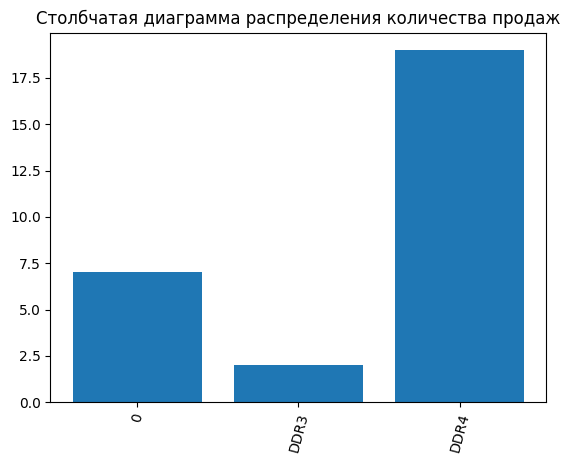

In [ ]:
plt.bar(data.index, data.values)
plt.title('Столбчатая диаграмма распределения количества продаж')
plt.xticks(rotation=75)
plt.show()

Самый популярный тип оперативной памяти - DDR4.

In [ ]:
data = dataset_Продажи_5.groupby('Тип видеокарты')['Продажи'].count()
data

Тип видеокарты
0              8
встроенная    12
дискретная     8
Name: Продажи, dtype: int64

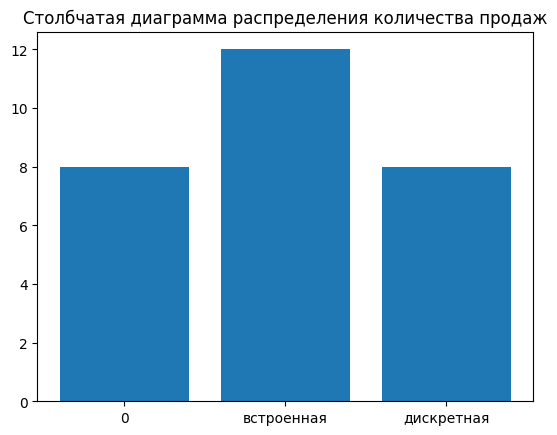

In [ ]:
plt.bar(data.index, data.values)
plt.title('Столбчатая диаграмма распределения количества продаж')
plt.show()

Самый популярный тип видеокарты - встроенная.

In [ ]:
data = dataset_Продажи_5.groupby('Тактовая частота')['Продажи'].count()
data

Тактовая частота
0.0    8
2.5    2
2.9    1
3.4    2
      ..
3.6    2
3.7    6
3.9    5
4.0    1
Name: Продажи, Length: 9, dtype: int64

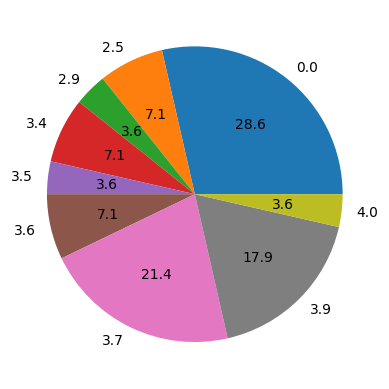

In [ ]:
plt.pie(data, labels=data.index, autopct='%.1f')
plt.show()

Самые популярные тактовые частоты - 3.7 и 3.9 ГГц.

In [ ]:
data = dataset_Продажи_5.groupby('Количество ядер')['Продажи'].count()
data

Количество ядер
0     7
2     1
4     6
6    14
Name: Продажи, dtype: int64

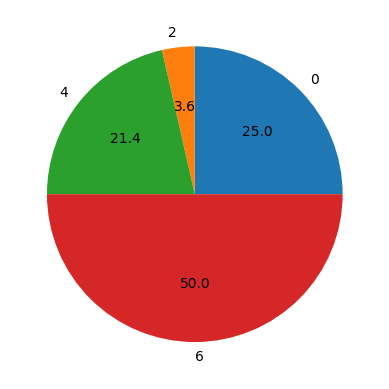

In [ ]:
plt.pie(data, labels=data.index, autopct='%.1f')
plt.show()

Самые популярные числа ядер - 6 и 4.

In [ ]:
data = dataset_Продажи_5.groupby('Частота оперативной памяти')['Продажи'].count()
data

Частота оперативной памяти
0.000    11
2.666    16
3.200     1
Name: Продажи, dtype: int64

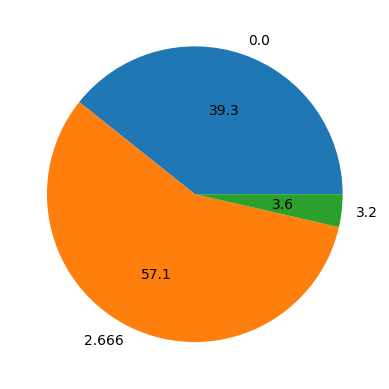

In [ ]:
plt.pie(data, labels=data.index, autopct='%.1f')
plt.show()

Самая популярная частота оперативной памяти - 2.666 ГГц.

In [ ]:
data = dataset_Продажи_5.groupby('Объем оперативной памяти')['Продажи'].count()
data

Объем оперативной памяти
0      7
4      1
8      3
16    12
32     5
Name: Продажи, dtype: int64

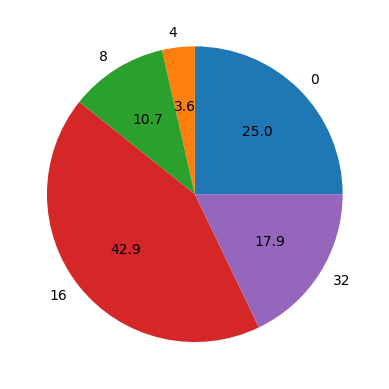

In [ ]:
plt.pie(data, labels=data.index, autopct='%.1f')
plt.show()

Самые популярные объемы оперативной памяти - 16 и 32 ГГб.

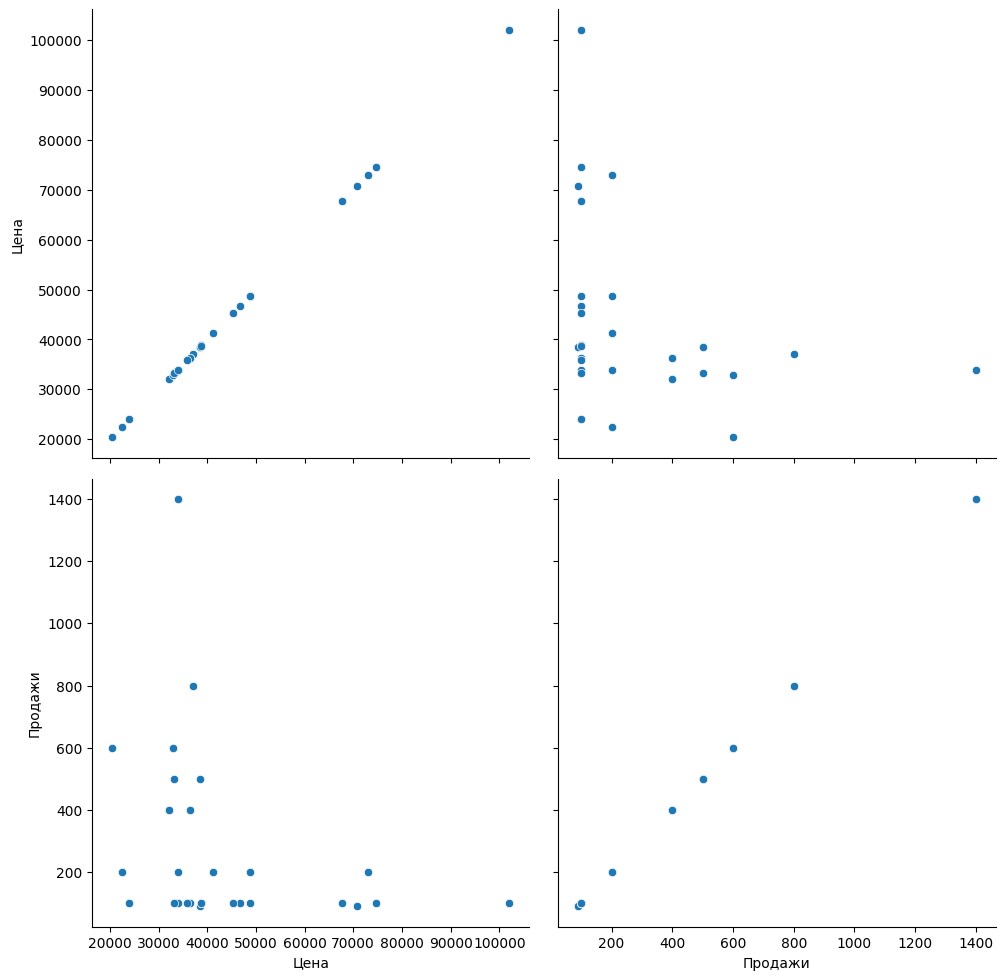

In [ ]:
g = sns.PairGrid(dataset_Продажи_5[['Цена', 'Продажи']], height=5)
g.map(sns.scatterplot)

Цена наиболее продаваемых ПК находится в диапазоне 30000 - 40000 руб.

Самый популярный компьютер:

In [ ]:
dataset_Продажи_5[dataset_Продажи_5.Продажи==1400]

,Артикул,Наименование,Цена,Продажи,Процессор,Тактовая частота,Количество ядер,Тип оперативной памяти,Частота оперативной памяти,Объем оперативной памяти,Тип накопителя,Объем накопителя,Видеопроцессор,Тип видеокарты,Объем памяти видеоадаптера,sales_category
4,20904017,игровой компьютер robotcomp аллигатор v1,33910,1400,amd,3.7,6,DDR4,2.666,16,SSD,SSD 480 ГБ,amd radeon vega 7,встроенная,выделяется из оперативной памяти,3.0


### **Выводы и рекомендации**

Ценовая вилка на компьютеры составляет от 12000 рублей до 239992 рублей.
Распределение цены не является нормальным.

Средняя цена компьютера - 79046.0 руб., медианная цена компьютера - 78470.0, т.е. медиана меньше средней на 576.0 руб., это небольшое значение по сравнению со стоимостью компьютера.

*   10-й процентиль цен компьютеров:  37125.0
*   25-й процентиль цен компьютеров:  46843.0
*   50-й процентиль цен компьютеров:  78470.0
*   75-й процентиль цен компьютеров:  103870.0
*   90-й процентиль цен компьютеров:  113740.0

У 10% выборки цены меньше или равны 37125.0 руб., а у 90% - больше этой величины. Четверть компьютеров стоит не менее 46843.0 руб., три четверти - более 46843.0 руб.. Половина компьютеров (медианное значение) стоит 78470.0 руб.. Три четверти компьютеров стоят не менее 103870.0 руб., четверть компьютеров стоят более 103870.0 руб.. 90% компьютеров стоят не менее 113740.0 руб., 10% компьютеров - более 113740.0 руб.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их можно не исключать. Ящик с усами показывает медиану ниже среднего значения, что свидетельствует о наличии небольших выбросов. Гистограмма поразрядно показывает распределение значений, в нашем случае мы наблюдаем, что значения то убывают, то возрастают, площади прямоугольников на гистограмме показывают значения выборки для данного разряда.

Разброс количества продаж огромен - от 0 до 1400, причем нулевые продажи составляют большую часть выборки. Распределение продаж не является нормальным.

Среднее количество продаж - 8, медианное количество продаж - 0, т.е. медиана гораздо меньше средней, что говорит о больших выбросах.

*   10-й процентиль количества продаж:  0
*   25-й процентиль количества продаж:  0
*   50-й процентиль количества продаж:  0
*   75-й процентиль количества продаж:  1
*   90-й процентиль количества продаж:  10

Три четверти компьютеров продавались не менее одного раза, четверть компьютеров продавалась более одного раза. 90% компьютеров продавались не менее 10 раз, 10% компьютеров - более 10 раз.

Графический анализ показывает, что в выборке содержатся большие выбросы, исключать их не нужно. Ящик с усами демонстрирует медиану гораздо ниже среднего значения, что свидетельствует о наличии больших выбросов. Гистограмма также показывает большое количество нулевых продаж.

Тактовая частота представлена в интервале от 0.231 до 4.3 ГГц. Ее распределение не является нормальным.

Средняя тактовая частота - 3.111 ГГц, медианная тактовая частота - 3.3 ГГц, медиана больше средней, т.е. распределение переменной имеет отрицательную асимметрию.

*   10-й процентиль тактовых частот:  2.1
*   25-й процентиль тактовых частот:  2.5
*   50-й процентиль тактовых частот:  3.3
*   75-й процентиль тактовых частот:  3.7
*   90-й процентиль тактовых частот:  3.7

У 10% выборки тактовые частоты меньше или равны 2.1 ГГц, а у 90% - больше 2.1 ГГц. Четверть тактовых частот составляет не менее 2.5 ГГц, три четверти - более 2.5 ГГц. Половина тактовых частот (медианное значение) составляет 3.3 ГГц. Три четверти тактовых частот составляют не менее 3.7 ГГц, четверть тактовых частот составляет более 3.7 ГГц. 90% тактовых частот также составляют не менее 3.7 ГГц, 10% тактовых частот - более 3.7 ГГц.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их можно исключить.

Количество ядер представлено в интервале от 2 до 18. Его распределение не является нормальным.

Среднее количество ядер - 7.248, медианное количество ядер - 6, медиана меньше средней, т.е. есть выбросы.

*   10-й процентиль количества ядер:  4.0
*   25-й процентиль количества ядер:  6.0
*   50-й процентиль количества ядер:  6.0
*   75-й процентиль количества ядер:  10.0
*   90-й процентиль количества ядер:  12.0

У 10% выборки количество ядер составляет меньше или равно 4, а у 90% - больше 4. Четверть компьютеров имеют не менее 6 ядер, три четверти - более 6. Половина компьютеров (медианное значение) имеет 6 ядер. Три четверти компьютеров имеют не менее 10 ядер, четверть компьютеров имеет более 10 ядер. 90% компьютеров имеют не менее 12 ядер, у 10% компьютеров - более 12 ядер.

Графический анализ показывает, что в выборке содержатся выбросы, их можно оставить.

Частота оперативной памяти представлена в интервале от 1.6 до 5 ГГц. Ее распределение не является нормальным.

Средняя частота оперативной памяти - 2.8976 ГГц, медианная частота оперативной памяти - 2.666 ГГц, медиана меньше средней, т.е. есть небольшие выбросы.

*   10-й процентиль частот оперативной памяти:  2.666
*   25-й процентиль частот оперативной памяти:  2.666
*   50-й процентиль частот оперативной памяти:  2.666
*   75-й процентиль частот оперативной памяти:  3.2
*   90-й процентиль частот оперативной памяти:  3.2

У 10% выборки частоты оперативной памяти меньше или равны 2.666 ГГц, а у 90% - больше 2.666 ГГц. Четверть частот оперативной памяти составляет не менее 2.666 ГГц, три четверти - более 2.666 ГГц. Половина частот оперативной памяти (медианное значение) составляет 2.666 ГГц. Три четверти частот оперативной памяти составляют не менее 3.2 ГГц, четверть частот оперативной памяти составляет более 3.2 ГГц. 90% частот оперативной памяти также составляют не менее 3.2 ГГц, 10% частот оперативной памяти - более 3.2 ГГц.

Графический анализ показывает, что в выборке содержатся небольшие выбросы, их лучше оставить.

Объем оперативной памяти представлен в интервале от 4 до 64 ГБ. Его распределение не является нормальным.

Средний объем оперативной памяти - 23 ГБ, медианный объем оперативой памяти - 16 ГБ, медиана меньше средней, т.е. есть выбросы.

*   10-й процентиль объема оперативной памяти:  16.0
*   25-й процентиль объема оперативной памяти:  16.0
*   50-й процентиль объема оперативной памяти:  16.0
*   75-й процентиль объема оперативной памяти:  32.0
*   90-й процентиль объема оперативной памяти:  32.0

У 10% выборки объем оперативной памяти составляет меньше или равно 16 ГБ, а у 90% - больше 16 ГБ. Четверть компьютеров имеют не менее 16 ГБ оперативной памяти, три четверти - более 16. Половина компьютеров (медианное значение) имеет 16 ГБ оперативной памяти. Три четверти компьютеров имеют не менее 32 ГБ оперативной памяти, четверть компьютеров имеет более 32 ГБ оперативной памяти. 90% компьютеров имеют не менее 32 ГБ оперативной памяти, у 10% компьютеров - более 32 ГБ оперативной памяти.

Графический анализ показывает, что в выборке содержатся выбросы, их нужно оставить.

Можно предположить, что
1. чем выше количество ядер процессора, тем выше цена;
2. связь цены с частотой и объемом оперативной памяти заметна;
3. цена не зависит от количества продаж и тактовой частоты процессора, скорее, наоборот, нужно исследовать, зависят ли продажи и тактовая частота процессора от цены ПК;
4. статистически значимая связь между количеством продаж и ценой, количеством ядер, частотой и объемом оперативной памяти отсутствует;
5. связь между продажами и тактовой частотой статистически незначима на уровне значимости 0.05.

Уникальных значений признака 'Процессор' три: Intel, AMD и не указано.
Наиболее часто встречаемое значение признака - Intel, встретилось 961 раз.
AMD встречается 345 раз. Процессор не указан в 195 случаях.
Круговая диаграмма показывает распределение копьютеров по процессорам с наименованиями процессоров и их процентыми долями:
Intel         - 64%,
AMD           - 23%,
не указано    - 13%.

Уникальных значений признака 'Тип оперативной памяти' четыре:
* DDR4          - встречается 1274 раза,
* не указано    - встречается 202 раза,
* DDR3          - встречается 24 раза,
* DDR5          - встречается 1 раз.

Круговая диаграмма показывает распределение копьютеров по типам оперативной памяти с наименованиями типов оперативной памяти и их процентыми долями:
* DDR4          - 84.9%,
* не указано    - 13.5%,
* DDR3          - 1.5%,
* DDR5          - 0.1%.

Уникальных значений признака 'Тип видеокарты' четыре:
* дискретная            - встречается 1085 раз,
* встроенная            - встречается 208 раз,
* не указано            - встречается 205 раз,
* дискретная+встроенная - встречается 3 раза.

Круговая диаграмма показывает распределение компьютеров по типам видеокарты с наименованиями типов видеокарты и их процентыми долями:
* дискретная            - 72.3%,
* встроенная            - 13.9%,
* не указано            - 13.7%,
* дискретная+встроенная - 0.1%.

Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. производитель процессора оказывает влияние на цену компьютера.

Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. тип оперативной памяти оказывает влияние на цену компьютера.

Так как pvalue меньше уровня значимости 0.05, то при уровне значимости 0.05 гипотеза отклоняется, т.е. тип видеокарты оказывает влияние на цену компьютера.

Таким образом, на цену компьютера оказывают влияние производитель процессора, тип оперативной памяти и тип видеокарты.

* У наиболее популярных товаров связь между признаками и количеством продаж слабая, часто отсутствует.
* Связь статистически незначима между количеством продаж и тактовой частотой, количеством ядер, частотой оперативной памяти.
* Чем меньше цена, тем больше продажи (связь отрицательно направленная).

Связь между количеством продаж и производителем процессора является статистически незначимой на уровне значимости 0.05, т.е. количество продаж не зависит от производителя процессора.

Связь между количеством продаж и типом оперативной памяти является статистически незначимой на уровне значимости 0.05, т.е. количество продаж не зависит от типа оперативной памяти.



Связь между количеством продаж и типом видеокарты является статистически значимой на уровне значимости 0.05, т.е. количество продаж так или иначе зависит от типа видеокарты.

Самый популярный процессор - AMD.

Самый популярный тип оперативной памяти - DDR4.

Самый популярный тип видеокарты - встроенная.


Самые популярные тактовые частоты - 3.7 и 3.9 ГГц.

Самые популярные числа ядер - 6 и 4.

Самая популярная частота оперативной памяти - 2.666 ГГц.

Самые популярные объемы оперативной памяти - 16 и 32 ГГб.

Цена наиболее продаваемых ПК находится в диапазоне 30000 - 40000 руб.

Самый популярный компьютер: игровой компьютер robotcomp аллигатор v1 (артикул 20904017).
